### **Bank Marketing Campaign**

[Data Source: Portugese Bank Marketing Campaign](https://www.kaggle.com/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset) 

This dataset is public available for research. The details are described in [Moro et al., 2014]:

[S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, Elsevier, 62:22-31, June 2014](https://www.sciencedirect.com/science/article/abs/pii/S016792361400061X?via%3Dihub) 

### **Contents**

1. Business Problem Understanding
2. Data Understanding
3. Data Preprocessing
4. Exploratory Data Analysis
5. Modeling
6. Conclusion
7. Recommendation

****

# Business Problem Understanding: Bank Marketing Campaign

## 1. Context
This dataset pertains to direct marketing campaigns (phone calls) conducted by a Portuguese banking institution. Often, more than one contact with the same client was required to determine if the product—a **bank term deposit**—would be subscribed to ('yes') or not ('no').

A term deposit is a financial instrument where a customer deposits a sum of money for a fixed period at a specific interest rate. For banks, these deposits are essential sources of liquidity, providing the necessary capital to issue loans to other customers.

## 2. Problem Statement
The telemarketing process involves significant operational overhead, primarily in terms of human resources (call center staff) and time. The core challenges are:
* **Low Efficiency:** The majority of contacted customers (approximately 88%) end up declining the offer ('no').
* **Customer Fatigue:** Repeatedly contacting disinterested customers can lead to dissatisfaction and damage the bank's reputation.
* **Resource Wastage:** Spending high operational costs and time for a low "hit rate" reduces the overall Return on Investment (ROI) of the marketing campaign.

## 3. Goals
Based on the identified problems, this project aims to:
* **Increase Conversion Rate:** Identify the specific characteristics of customers who have a high probability of subscribing to a term deposit.
* **Cost Optimization:** Reduce the number of calls made to customers predicted to decline, allowing the marketing team to focus on high-potential prospects.
* **Data-Driven Insights:** Provide actionable recommendations to the marketing department regarding the best timing or specific customer profiles (based on socio-economic factors) for future campaigns.

## 4. Stakeholders
* **Marketing Team:** Responsible for campaign strategy, budget efficiency, and executing daily calls.
* **Data Science Team:** Responsible for building predictive models and extracting insights.
* **Executive Board:** Interested in the growth of the bank's deposit portfolio and overall cost-efficiency.

## 5. Target Variable
The target variable for this analysis is:
* **`y`**: Has the client subscribed to a term deposit?
  * `1` (Yes): Subscribed.
  * `0` (No): Did not subscribe.

## 6. Analytical Approach
The project will follow these steps:
1. **Exploratory Data Analysis (EDA):** Analyze data distributions, feature correlations, and the impact of economic indicators (such as interest rates) on the target variable.
2. **Data Preprocessing:** Handle missing values (if any), perform encoding for categorical data, manage outliers, and apply feature scaling.
3. **Handling Imbalanced Data:** Implement techniques such as SMOTE (Synthetic Minority Over-sampling Technique) or Random UnderSampling, as 'no' responses significantly outnumber 'yes' responses.
4. **Machine Learning Modeling:** Develop classification models using algorithms such as *Logistic Regression, Random Forest, XGBoost,* or *Gradient Boosting*.
5. **Model Evaluation & Tuning:** Perform hyperparameter tuning to optimize performance.

## 7. Metric Evaluation
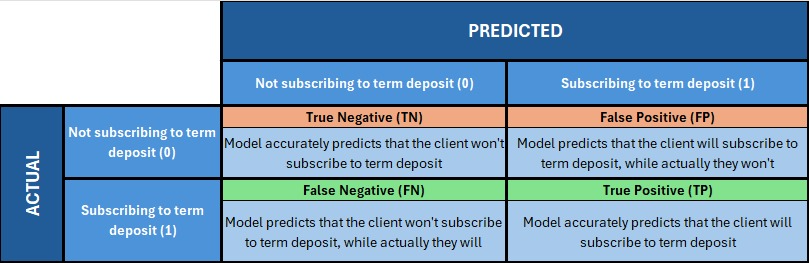

Given the class imbalance in the dataset, the model will be evaluated using metrics beyond simple Accuracy:
* **Precision:** To minimize 'False Positives' (predicting a customer will subscribe when they won't), ensuring call resources are not wasted.
* **Recall:** To minimize 'False Negatives' (missing out on customers who actually would have subscribed), preventing opportunity loss.
* **F1-Score:** To find the optimal balance between Precision and Recall.
* **ROC-AUC:** To measure the model's overall ability to distinguish between the two classes.

# Data Understanding

In [74]:
# Library
import pandas as pd
import numpy as np
import math
import time
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import shap

# Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV,StratifiedKFold,train_test_split, cross_val_score, cross_validate, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, precision_recall_curve, auc
from sklearn.metrics import roc_curve, roc_auc_score

# Imbalance Dataset
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

import pickle

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [75]:
# Load our banking campaign dataset
df = pd.read_csv('bank-additional-full.csv', sep=';', encoding='utf-8')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



## 1. Attribute Information

The dataset consists of 20 independent features and 1 target variable, categorized into client data, campaign details, socio-economic factors, and the target.

**A. Bank Client Data**
| Attribute | Description | Data Type | Values / Examples |
| :--- | :--- | :--- | :--- |
| **age** | Age of the client | Numeric | 18, 30, 50, etc. |
| **job** | Type of job | Categorical | 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown' |
| **marital** | Marital status | Categorical | 'divorced', 'married', 'single', 'unknown' |
| **education** | Level of education | Categorical | 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown' |
| **default** | Has credit in default? | Categorical | 'no', 'yes', 'unknown' |
| **housing** | Has housing loan? | Categorical | 'no', 'yes', 'unknown' |
| **loan** | Has personal loan? | Categorical | 'no', 'yes', 'unknown' |

**B. Last Contact Information (Current Campaign)**
| Attribute | Description | Data Type | Values / Examples |
| :--- | :--- | :--- | :--- |
| **contact** | Contact communication type | Categorical | 'cellular', 'telephone' |
| **month** | Last contact month of year | Categorical | 'jan', 'feb', ..., 'nov', 'dec' |
| **day_of_week** | Last contact day of the week | Categorical | 'mon', 'tue', 'wed', 'thu', 'fri' |
| **duration** | Last contact duration in seconds | Numeric | **Note:** Known only after call. Discard for realistic prediction models. |

**C. Other Attributes (Previous Campaigns)**
| Attribute | Description | Data Type | Values / Examples |
| :--- | :--- | :--- | :--- |
| **campaign** | Number of contacts during this campaign | Numeric | 1, 2, 3, ... (includes last contact) |
| **pdays** | Days since last contact from previous campaign | Numeric | 999 means client was not previously contacted |
| **previous** | Number of contacts before this campaign | Numeric | 0, 1, 2, ... |
| **poutcome** | Outcome of the previous marketing campaign | Categorical | 'failure', 'nonexistent', 'success' |

**D. Socio-Economic Context Attributes**
| Attribute | Description | Data Type | Values / Examples |
| :--- | :--- | :--- | :--- |
| **emp.var.rate** | Employment variation rate (quarterly) | Numeric | Indicator of economic health |
| **cons.price.idx** | Consumer price index (monthly) | Numeric | Measure of inflation |
| **cons.conf.idx** | Consumer confidence index (monthly) | Numeric | Consumer sentiment indicator |
| **euribor3m** | Euribor 3 month rate (daily) | Numeric | Interbank lending rate |
| **nr.employed** | Number of employees (quarterly) | Numeric | Labor market indicator |

**E. Target Variable**
| Attribute | Description | Data Type | Values / Examples |
| :--- | :--- | :--- | :--- |
| **y** | Has the client subscribed to a term deposit? | Binary | 'yes' (1), 'no' (0) |

---

## 2. Data Condition: Class Balance Analysis

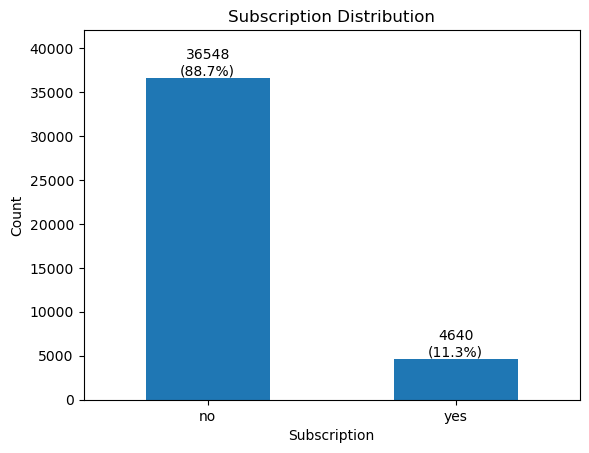

In [76]:
# Count values
counts = df['y'].value_counts()
total = len(df)

# Plot
ax = counts.plot(kind='bar')

# Add labels (count + percentage)
for i, val in enumerate(counts):
    percentage = val / total * 100
    ax.text(i, val, f'{val}\n({percentage:.1f}%)', 
            ha='center', va='bottom')
    
# Add space above bars
ax.set_ylim(0, max(counts) * 1.15)

plt.title('Subscription Distribution')
plt.xlabel('Subscription')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Status: Highly Imbalanced**
An analysis of the target variable `y` reveals a significant class imbalance:
*   **Class 'no' (Majority):** ~89% 
*   **Class 'yes' (Minority):** ~11%

**What This Means for Modeling:**
* **Accuracy** will not be used as a metric due to class imbalance (a model would predict "no" with 89% accuracy and might ignore the minority class of 'yes').
* **Precision**, **Recall**, **F1-Score**, and **ROC-AUC** metrics will be used to ensure the minority class is captured.
* **Resampling** (SMOTE, Random Under-sampling, etc.) must be used.

## 3. Categorical

### A. Descriptive Statistics

In [77]:
# Descriptive Statistics for Categorical Features
print("\n=== Descriptive Statistics for Categorical Features ===")
df.describe(include=['object'])


=== Descriptive Statistics for Categorical Features ===


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


### B. Distribution of Categorical Features

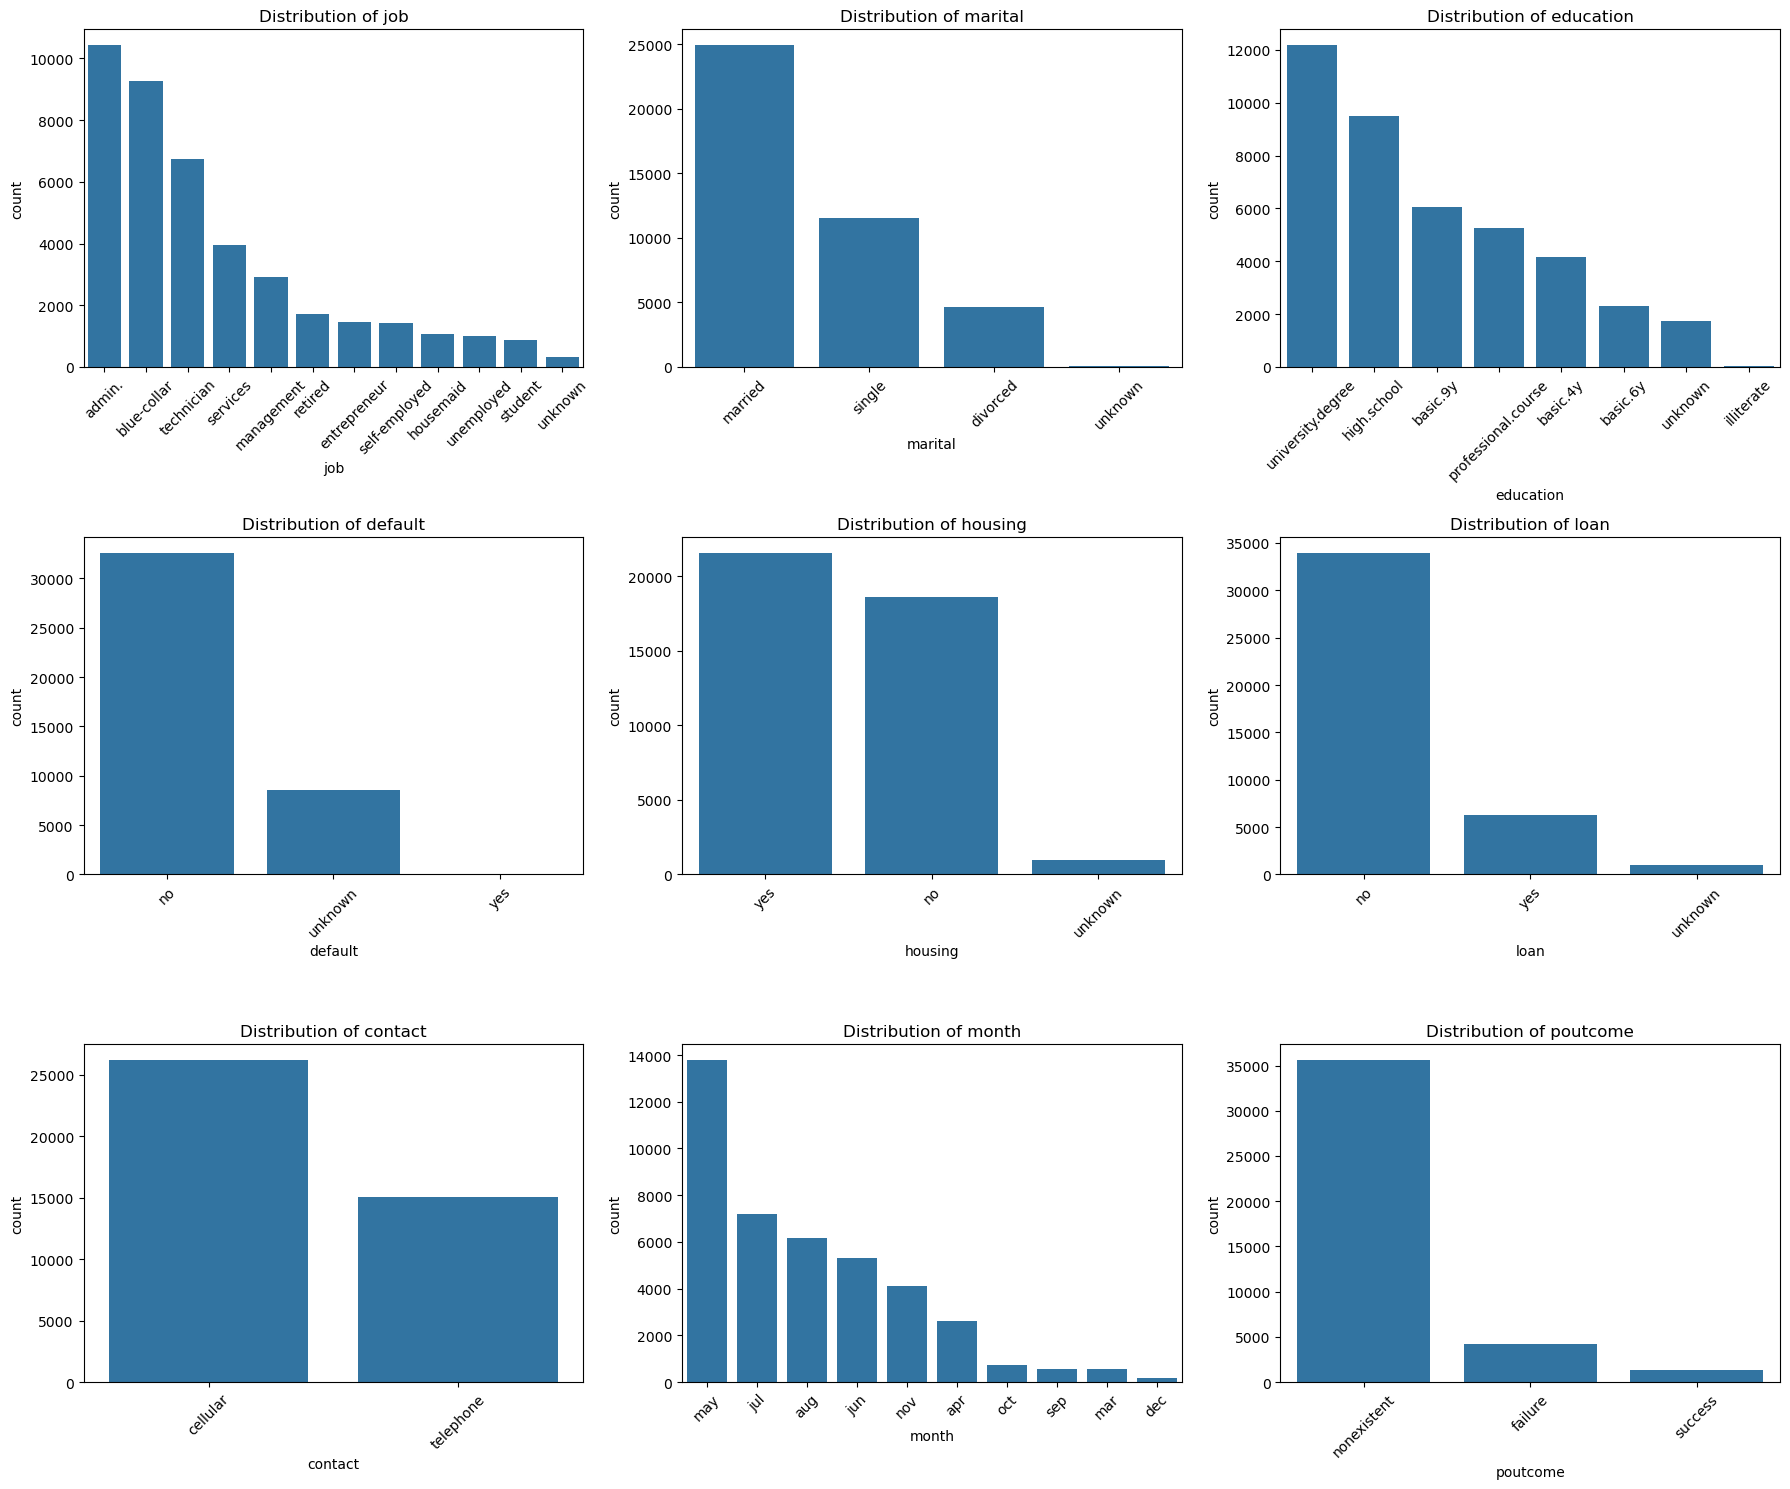

In [78]:
# Select categorical features (excluding target)
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
n = len(categorical_cols)
cols = 3  # number of plots per row
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 6, rows * 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)

    # Order by frequency
    order = df[col].value_counts().index

    sns.countplot(data=df, x=col, order=order)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

## 4. Numerical

#### A. Descriptive Statistics

In [79]:
# Descriptive Statistics for Numerical Features
print("\n=== Descriptive Statistics for Numerical Features ===")
df.describe(include=['int64', 'float64'])


=== Descriptive Statistics for Numerical Features ===


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


#### B. Distribution of Numerical Features
**Client Attributes**

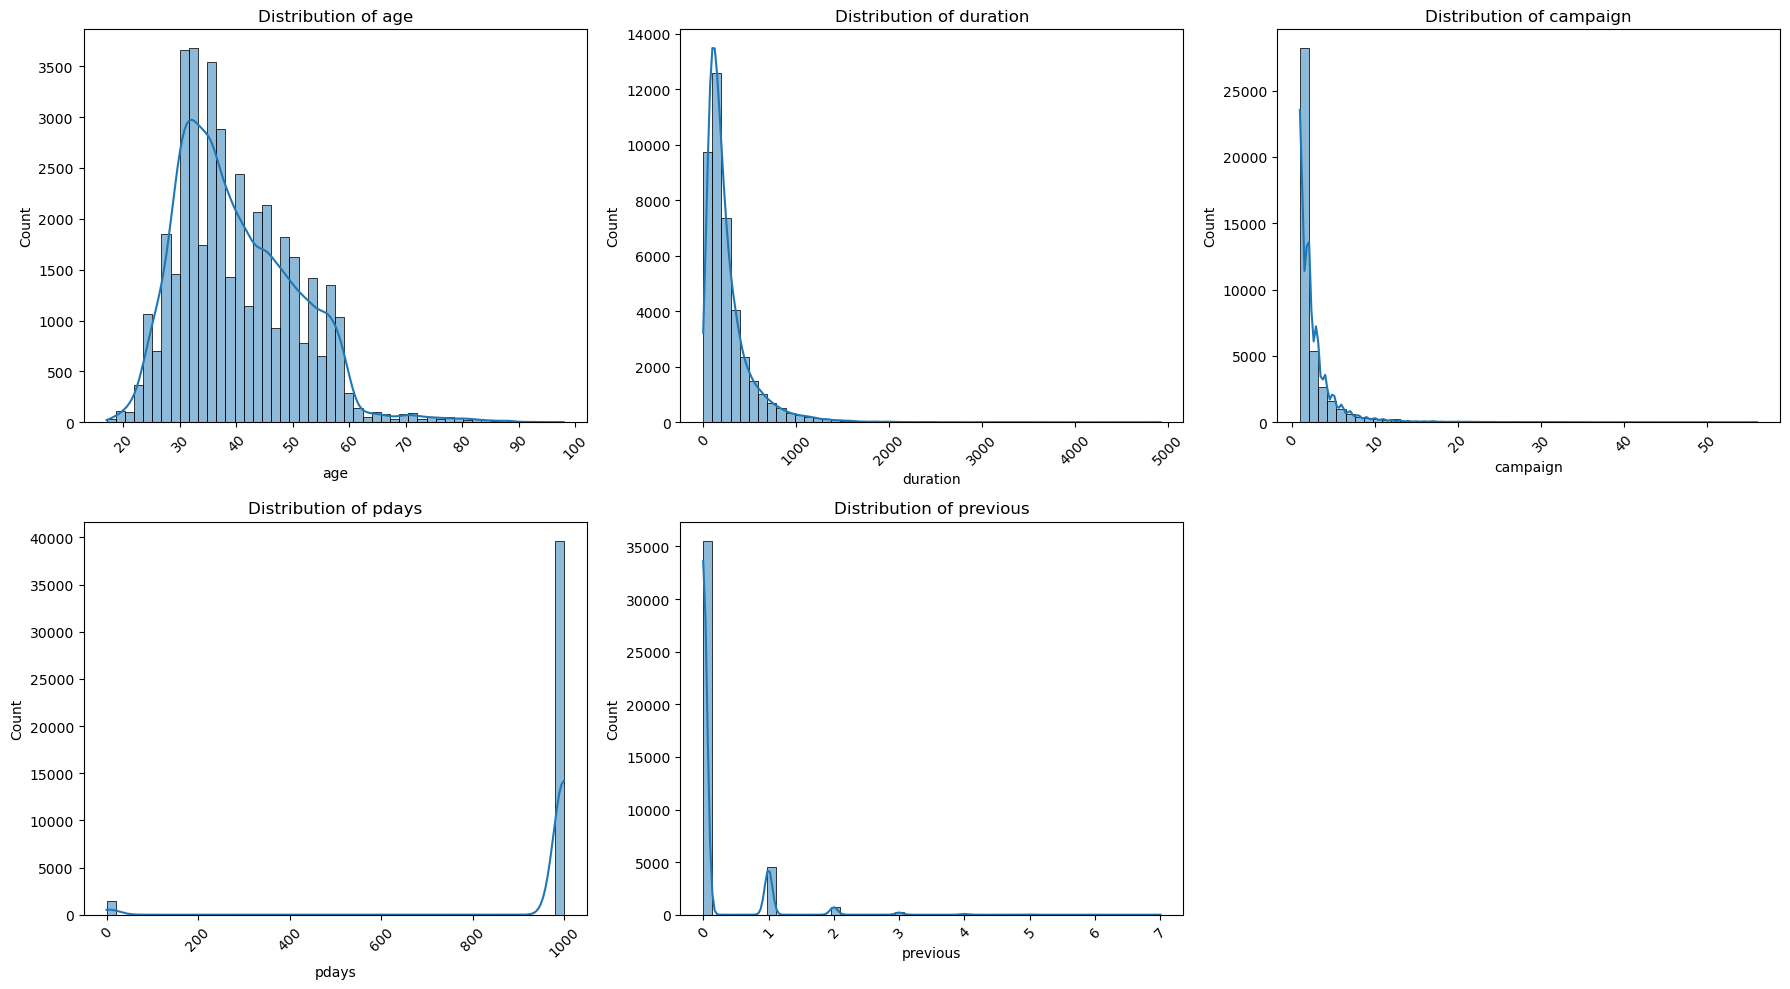

In [80]:
# Select numerical features (attributes)
numerical_cols = ['age', 'duration', 'campaign', 'pdays', 'previous']

n = len(numerical_cols)
cols = 3  # number of plots per row
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 6, rows * 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(data=df, x=col, kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

**Socio-Economic**

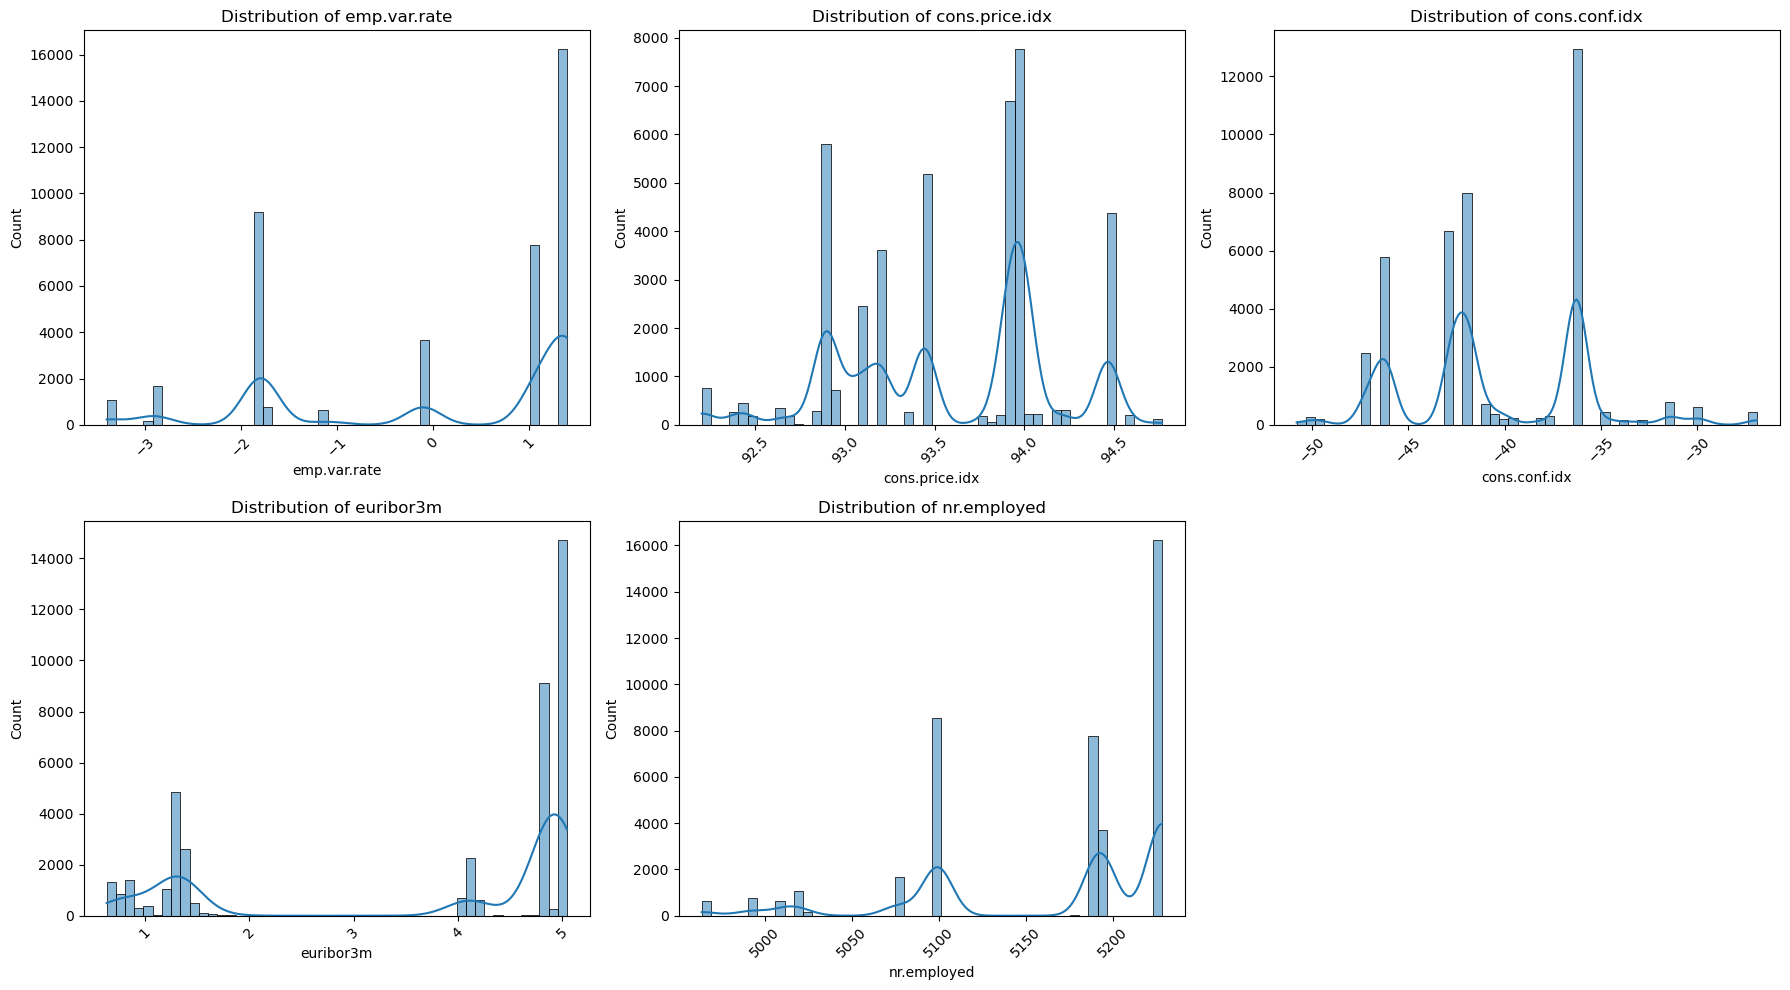

In [81]:
# Select numerical features (socio-economic attributes)
numerical_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

n = len(numerical_cols)
cols = 3  # number of plots per row
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 6, rows * 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(data=df, x=col, kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

# Data Preprocessing

## 1. Data Cleaning

### Copy Dataset for Cleaning

In [82]:
df_clean = df.copy()

### Display Basic Information

In [83]:
print("Dataset Shape:", df_clean.shape)
print("\nMissing Values (Standard NaNs):")
print(df_clean.isnull().sum())
print("\nData Types:")
print(df_clean.dtypes)

Dataset Shape: (41188, 21)

Missing Values (Standard NaNs):
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Data Types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64


*Interpretation:*
We check for standard NaN values. However, in this dataset missing values are often recorded as the string `'unknown'` rather than nulls though their exact nature will be addressed later. We also verify data types to ensure numerical columns are correctly identified.

### Checking & Handling Duplicate Rows

In [84]:
# Check for duplicates
duplicate_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Drop duplicates
if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplicates removed successfully.")

print("New Dataset Shape:", df_clean.shape)

Number of duplicate rows: 12
Duplicates removed successfully.
New Dataset Shape: (41176, 21)


Interpretation:
We identify and remove exact duplicate rows to ensure each customer contact record is unique, preventing the model from over-learning specific identical patterns.

### Checking and Handling 'Unknown' Values

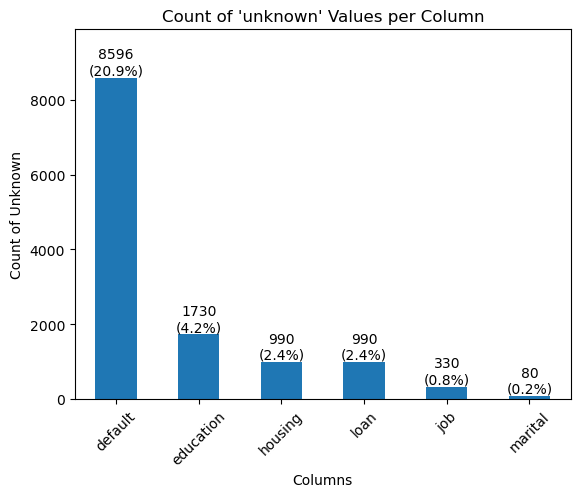

In [85]:
unknown_values = (df_clean == 'unknown').sum()

# Filter out columns with no unknown values
unknown_values = unknown_values[unknown_values > 0].sort_values(ascending=False)

# Plot
plt.figure()
ax = unknown_values.plot(kind='bar')

# Add space above bars
ax.set_ylim(0, max(unknown_values) * 1.15)

# Add Labels
total = len(df_clean)
for i, val in enumerate(unknown_values):
    percentage = val / total * 100
    ax.text(i, val, f'{val}\n({percentage:.1f}%)',
            ha='center', va='bottom')

plt.title("Count of 'unknown' Values per Column")
plt.xlabel('Columns')
plt.ylabel('Count of Unknown')

plt.xticks(rotation=45)
plt.show()

Interpretation: Columns like `education`, `job`, and `housing` often have "unknown" values, with the highest in `default`. It is interesting to note how `housing` and `loan` have the same count of unknowns. We should be careful how to handle these unknowns to not lose any meaningful information.

#### A. Default
20.9% of all data have unknown in `default` feature. Due to the size of it, this meant meaningful data for the model. In banking, if a person's credit default history is unknown, it might mean they have no credit history or didn't disclose it. To test the hypothesis that it simply means they have no credit history, let's crosstab them to housing and loan features.

In [86]:
# How default status relates to housing loan
pd.crosstab(df_clean['default'], df_clean['housing'])

housing,no,unknown,yes
default,,,
no,14608,763,17206
unknown,4005,227,4364
yes,2,0,1


In [87]:
# How default status relates to loan ownership
pd.crosstab(df_clean['default'], df_clean['loan'])

loan,no,unknown,yes
default,,,
no,26838,763,4976
unknown,7097,227,1272
yes,3,0,0


Interpretation: Having no credit would mean not having loan or housing loan. But since from this crosstab they are a mix of yes or no, it means that some indeed refuse to answer about their credit history, or it could just be a missing data collected from the bank. Nevertheless, we're still going to 'unknown' as its own distinct category.

As mentioned before, it is interesting to see the number of clients in 'unknown' from `housing` and `loan` is the same even in this crosstab, which we will cover next.

#### B. Housing and Loan
From previous crosstab, it seems like the client in 'unknown' from `housing` and `loan` might be the same people.

In [88]:
pd.crosstab(df_clean['loan'], df_clean['housing'])

housing,no,unknown,yes
loan,,,
no,16058,0,17880
unknown,0,990,0
yes,2557,0,3691


Interpretation: They are in fact the same people. Because the missingness might be a pattern, we keep unknowns in `housing` and `loan` as its own distinct category.

#### C. Education and Job
People with similar jobs often have similar education levels. With this information, we can impute unknown education with the mode education level for that specific job type, and vice versa.

In [89]:
# Group-based Imputation for 'education'
# Calculate the most common education for each job
edu_mode_per_job = df_clean[df_clean['education'] != 'unknown'].groupby('job')['education'].agg(lambda x: x.mode()[0]).to_dict()

def impute_education(row):
    if row['education'] == 'unknown':
        # Return the most common education for that person's job
        return edu_mode_per_job.get(row['job'], 'university.degree') # fallback to global mode
    return row['education']

df_clean['education'] = df_clean.apply(impute_education, axis=1)

print(f"Unknowns remaining in education: {(df_clean['education'] == 'unknown').sum()}")

# Group-based Imputation for 'job'
# Calculate the most common job for each education level
job_mode_per_edu = df_clean[df_clean['job'] != 'unknown'].groupby('education')['job'].agg(lambda x: x.mode()[0]).to_dict()

# Apply the mapping
def impute_job(row):
    if row['job'] == 'unknown':
        # Return the most common job for that person's education level
        return job_mode_per_edu.get(row['education'], 'admin.') # fallback to global mode
    return row['job']

df_clean['job'] = df_clean.apply(impute_job, axis=1)

print(f"Unknowns remaining in job: {(df_clean['job'] == 'unknown').sum()}")

Unknowns remaining in education: 0
Unknowns remaining in job: 0


#### D. Marital
Since only 0.2% of the data is missing for `marital` status, the impact of a simple fix is negligible. We can simply impute it with the mode of the column.

In [90]:
# Simple Mode Imputation for 'marital'
marital_mode = df_clean[df_clean['marital'] != 'unknown']['marital'].mode()[0]
df_clean['marital'] = df_clean['marital'].replace('unknown', marital_mode)
print(f"Unknowns remaining in marital: {(df_clean['marital'] == 'unknown').sum()}")

Unknowns remaining in marital: 0


### Checking & Handling Outliers

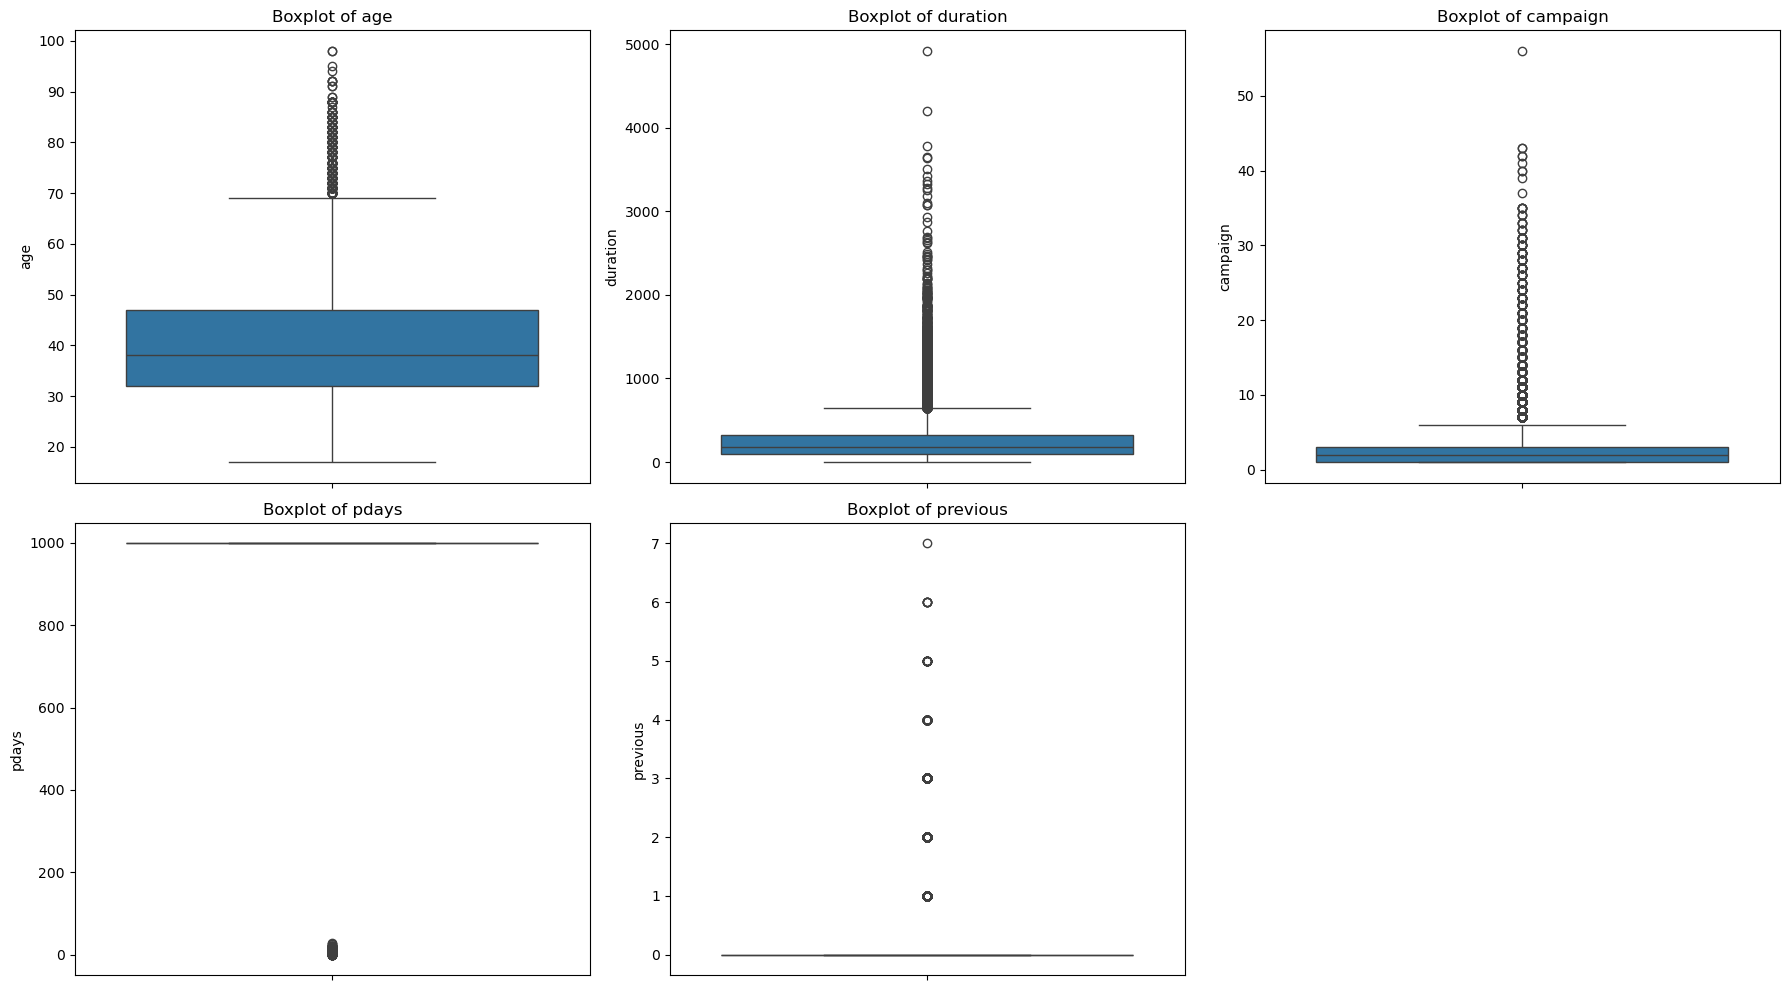


=== Outlier Detection (IQR method) ===
age: 468 outliers (1.14%)
duration: 2963 outliers (7.19%)
campaign: 2406 outliers (5.84%)
   Max campaign: 56 - possible data entry error or extreme case.
pdays: 1515 outliers (3.68%)
   pdays = 999 indicates 'never contacted before'. Count: 39661
previous: 5625 outliers (13.66%)


In [91]:
# Numerical Attributes
numerical_cols = ['age', 'duration', 'campaign', 'pdays', 'previous']

# Boxplots to detect outliers
n = len(numerical_cols)
cols = 3  # number of plots per row
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 6, rows * 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Detailed Outlier Analysis using IQR
print("\n=== Outlier Detection (IQR method) ===")
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")
    if col == 'campaign':
        print(f"   Max campaign: {df_clean['campaign'].max()} - possible data entry error or extreme case.")
    if col == 'pdays':
        print(f"   pdays = 999 indicates 'never contacted before'. Count: {(df_clean['pdays'] == 999).sum()}")

Interpretation:
The value 999 is an outlier that would confuse distance-based algorithms (like KNN or SVM). By converting it into a binary feature (Contacted vs. Not Contacted), we preserve the logic without the numerical distortion.

#### A. Age
Ages 85–98 are real, valid people, so not errors. There are just very few of them. Capping at the 99th percentile preserves the data without letting extreme elderly ages distort the model.

In [92]:
# Cap age at 99th percentile
age_cap = df_clean['age'].quantile(0.99)
df_clean['age'] = df_clean['age'].clip(upper=age_cap)
df_clean['age'].describe()

count    41176.000000
mean        39.955144
std         10.176254
min         17.000000
25%         32.000000
50%         38.000000
75%         47.000000
max         71.000000
Name: age, dtype: float64

#### B. Duration
Duration has outliers but it will not matter since it will be dropped before modeling. So, we leave it as is for EDA purposes, then drop it after.

#### C. Campaign
Someone being called 56 times is almost certainly a data entry error or extreme edge case. Capping at the 99th percentile is the right call here.

In [93]:
# Cap campaign at 99th percentile
campaign_cap = df_clean['campaign'].quantile(0.99)
df_clean['campaign'] = df_clean['campaign'].clip(upper=campaign_cap)
df_clean['campaign'].describe()

count    41176.000000
mean         2.500291
std          2.301416
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         14.000000
Name: campaign, dtype: float64

#### D. Days since Last Contacted from Previous Campaign (`pdays`)
Treatment for this feature will be carried out in feature engineering.

#### E. Number of Contacts before this Campaign (`previous`)
IQR flags this because most of them are 0, making IQR = 0. But values of 1–7 are completely legitimate: a client was contacted up to 7 times before. This is not an outlier problem, it's just a heavily zero-inflated distribution. Conclusion: Leave it alone.

## 2. Features Engineering & Features Selection

### A. Categorical Feature Engineering: Grouping & Binning

High-cardinality features like `job` and `education` create noise. Research shows that grouping these into broader categories improves model generalization.

In [94]:
def engineer_categorical(df_clean):
    # 1. Simplify Jobs: Group by similar socio-economic status/risk
    job_map = {
        'admin.': 'white-collar', 'management': 'white-collar', 'entrepreneur': 'white-collar',
        'blue-collar': 'blue-collar', 'services': 'blue-collar', 'technician': 'blue-collar',
        'retired': 'retired', 'student': 'student', 'unemployed': 'unemployed',
        'self-employed': 'self-employed', 'housemaid': 'blue-collar', 'unknown': 'unknown'
    }
    df_clean['job_category'] = df_clean['job'].map(job_map)

    # 2. Ordinal Encoding for Education
    # Education has a logical order of value/potential income
    edu_map = {
        'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3,
        'high.school': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': 2 # Median
    }
    df_clean['education_level'] = df_clean['education'].map(edu_map)

    # 3. Simplify Marital Status
    # 'Single' and 'Divorced' often behave similarly compared to 'Married' in savings behavior
    df_clean['is_married'] = df_clean['marital'].apply(lambda x: 1 if x == 'married' else 0)
    
    return df_clean

df_clean = engineer_categorical(df_clean)

### B. Numerical Feature Engineering: Time & Contact

The features `pdays` and `age` require specific transformations to be useful.

In [95]:
def engineer_numerical(df_clean):
    # 1. Age Binning: Life stages influence financial decisions
    # Groups: Young, Adult, Senior, Elderly
    df_clean['age_bin'] = pd.cut(df_clean['age'], bins=[0, 25, 40, 60, 100], labels=['Student_Age', 'Young_Adult', 'Adult', 'Senior'])

    # 2. pdays: 999 means "never contacted".
    # This is a huge outlier. Let's create a binary flag and a log transform for the rest.
    df_clean['never_contacted'] = (df_clean['pdays'] == 999).astype(int)
    # Replace 999 with a value that doesn't skew distributions
    df_clean['pdays'] = df_clean['pdays'].replace(999, 0)

    # 3. Campaign contact frequency
    # High frequency contacts often lead to "marketing fatigue"
    df_clean['campaign_intensity'] = df_clean['campaign'].apply(lambda x: 'high' if x > 3 else 'low')

    return df_clean

df_clean = engineer_numerical(df_clean)

### C. Socio-Economic Indicators (The "Macro" Features)

The Bank Marketing dataset is unique because it includes quarterly economic indicators. These are often the strongest predictors

In [96]:
def engineer_economic(df_clean):
    # 1. Confidence vs. Price interaction
    # If prices are high and confidence is low, people save more (term deposits)
    # Since cons.price.idx and cons.conf.idx are on different scales (positives and negatives), we can capture the interaction
    # by subtracting confidence from price
    # High prices + very negative confidence → large difference → people are more likely to save in term deposits
    df_clean['price_conf_index'] = df_clean['cons.price.idx'] - df_clean['cons.conf.idx']
    
    # 2. Employment variation rate as a binary (Growing vs. Shrinking economy)
    df_clean['economy_growing'] = df_clean['emp.var.rate'].apply(lambda x: 1 if x > 0 else 0)
    
    return df_clean

df_clean = engineer_economic(df_clean)

In [97]:
# Check the new feature price_conf_index
# The result is always positive and ranges from ~119 to ~145 → "how far apart are price levels from consumer sentiment"
df_clean['price_conf_index'].describe()

count    41176.000000
mean       134.078583
std          4.629809
min        119.331000
25%        130.394000
50%        135.200000
75%        136.618000
max        145.567000
Name: price_conf_index, dtype: float64

### D. Binary Target
Lastly, we want to make our target into binary column to allow mathematical calculation such as conversion rate.

In [98]:
# Turning our target variable into binary
df_clean['y'] = df_clean['y'].replace({'yes': 1, 'no': 0})

# However, we want to have yes and no as readable legends in charts. So we we make a label for y
df_clean['y_label'] = df_clean['y'].map({1: 'yes', 0: 'no'})

## 3. Save Clean Dataframe into CSV

In [99]:
# Save the clean dataframe to be used in tableau dashboard
df_clean.to_csv('bank-additional-full-clean.csv', index=False)

In [100]:
df_clean

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_category,education_level,is_married,age_bin,never_contacted,campaign_intensity,price_conf_index,economy_growing,y_label
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,blue-collar,1,1,Adult,1,low,130.394,1,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,blue-collar,4,1,Adult,1,low,130.394,1,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,blue-collar,4,1,Young_Adult,1,low,130.394,1,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,white-collar,2,1,Young_Adult,1,low,130.394,1,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,blue-collar,4,1,Adult,1,low,130.394,1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,71,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,0,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,retired,5,1,Senior,1,low,145.567,0,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,0,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,blue-collar,5,1,Adult,1,low,145.567,0,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,0,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,retired,6,1,Adult,1,low,145.567,0,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,0,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,blue-collar,5,1,Adult,1,low,145.567,0,yes


# Exploratory Data Analysis

## 1. Customer Demographics

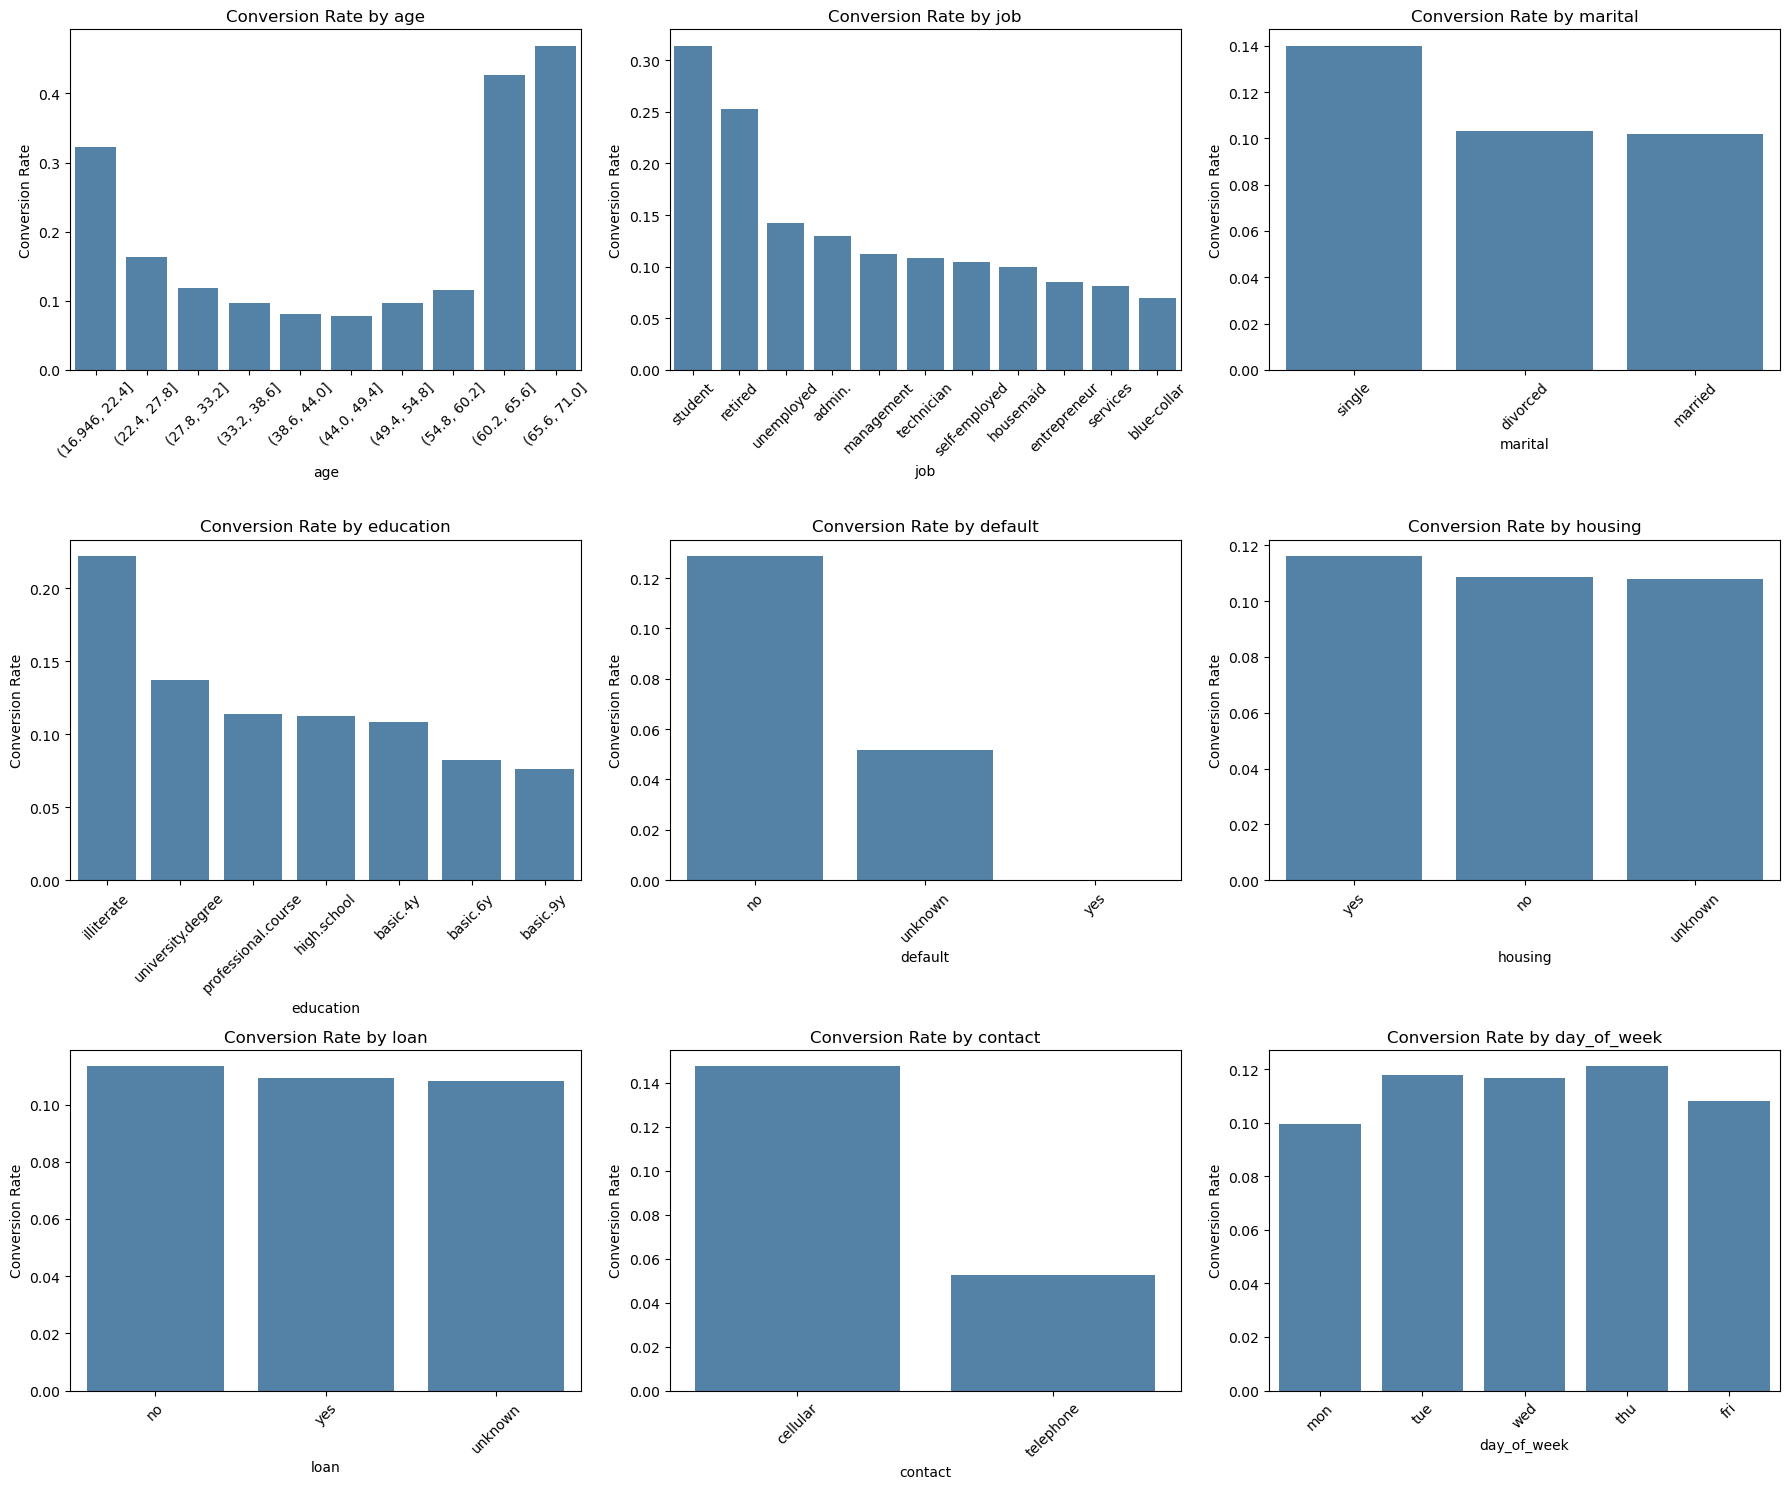

In [101]:
def plot_conversion_rates(df, features, target='y', bins=10):
    n = len(features)
    cols = 3  # number of plots per row
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 6, rows * 5))

    for i, feature in enumerate(features, 1):
        plt.subplot(rows, cols, i)

        if feature == 'age':
            # Bin age into groups
            age_bins = pd.cut(df[feature], bins=bins)
            rate = df.groupby(age_bins)[target].mean()
            x_labels = [str(interval) for interval in rate.index]
        elif feature == 'day_of_week':
            # Order days of week
            order = ['mon', 'tue', 'wed', 'thu', 'fri']
            rate = df.groupby(feature)[target].mean().reindex(order)
            x_labels = rate.index.astype(str)
        else:
            rate = df.groupby(feature)[target].mean().sort_values(ascending=False)
            x_labels = rate.index.astype(str)

        sns.barplot(x=x_labels, y=rate.values, color='steelblue')

        plt.title(f'Conversion Rate by {feature}')
        plt.xticks(rotation=45)
        plt.ylabel('Conversion Rate')
        plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

features = ['age', 'job', 'marital', 'education', 'default', 
            'housing', 'loan', 'contact', 'day_of_week']
plot_conversion_rates(df_clean, features)

Interpretation: It looks like conversion rate is highest on students and those that are retired. Age group confirms this as well. Those that are illiterate also more prone to term deposit. Marital status does not seem to affect much. In financial status, those that have not default in credit is more likely to subscribe to term deposit, while housing and personal loan display minimal variation in conversion rate. Cellular contact has a much higher conversion rate than telephone. Lastly, Thursday/Tuesday outperform any day, with Mondays the lowest.

## 2. Deeper Look into Job Conversion Rate

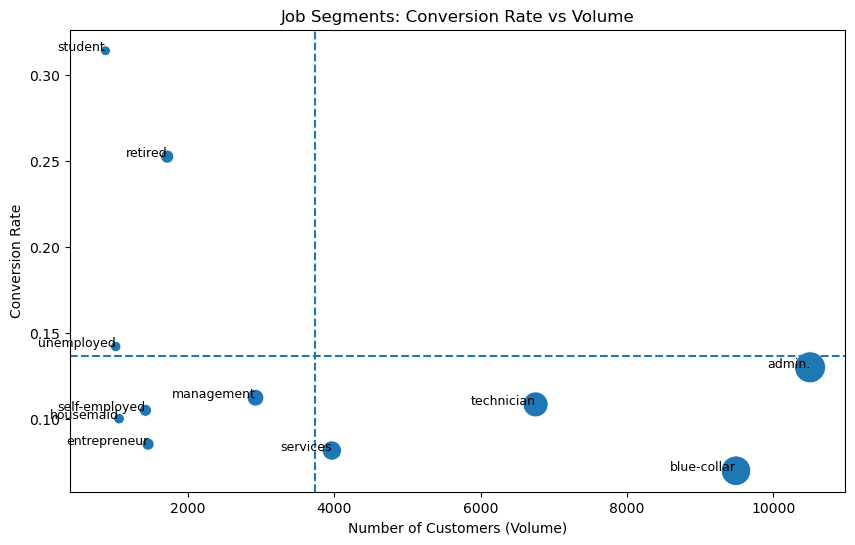

In [102]:
# Create data for volume and conversion rate
job_summary = df_clean.groupby('job').agg(
    volume=('y', 'count'),
    conversion_rate=('y', 'mean')
).reset_index()

# Calculate averages
avg_volume = job_summary['volume'].mean()
avg_rate = job_summary['conversion_rate'].mean()

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=job_summary,
    x='volume',
    y='conversion_rate',
    size='volume',
    sizes=(50, 500),
    legend=False
)

# Add labels
for i in range(len(job_summary)):
    plt.text(
        job_summary['volume'][i],
        job_summary['conversion_rate'][i],
        job_summary['job'][i],
        fontsize=9,
        ha='right'
    )

# Add quadrant lines
plt.axvline(avg_volume, linestyle='--')
plt.axhline(avg_rate, linestyle='--')

plt.title('Job Segments: Conversion Rate vs Volume')
plt.xlabel('Number of Customers (Volume)')
plt.ylabel('Conversion Rate')

plt.show()

Interpretation: Students and retired customers exhibit higher conversion rates, making them high-efficiency targets. Meanwhile, administrative and technician roles contribute larger customer volumes, making them important for scaling total conversions despite lower individual conversion rates.

## 3. Campaign Timing and Seasonality

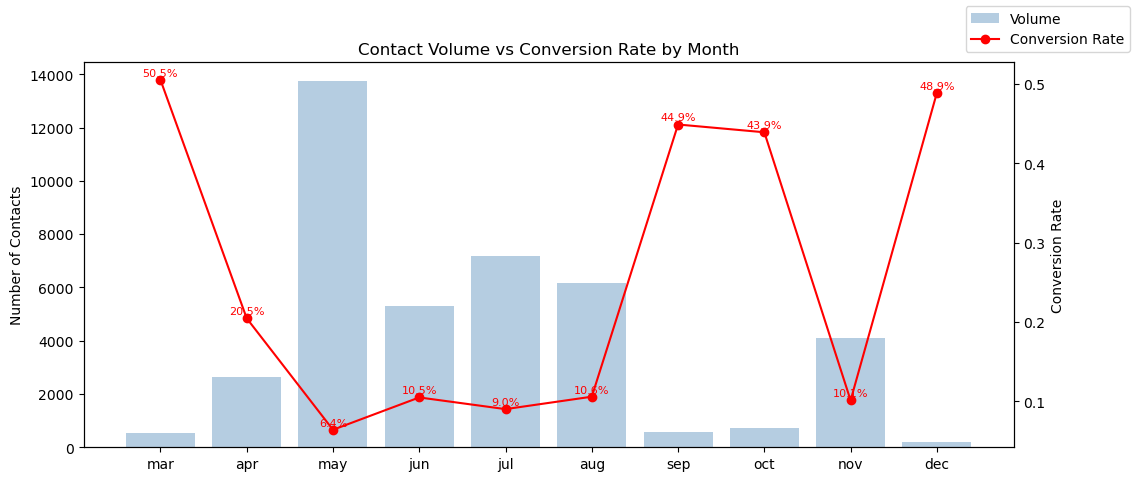

In [103]:
months_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df_clean['month'] = pd.Categorical(df_clean['month'], categories=months_order, ordered=True)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar: volume
month_counts = df_clean.groupby('month', observed=True)['y'].count()
ax1.bar(month_counts.index, month_counts.values, alpha=0.4, color='steelblue', label='Volume')
ax1.set_ylabel('Number of Contacts')

# Line: conversion rate
ax2 = ax1.twinx()
month_rate = df_clean.groupby('month', observed=True)['y'].mean()
ax2.plot(month_rate.index, month_rate.values, color='red', marker='o', label='Conversion Rate')
ax2.set_ylabel('Conversion Rate')

# Add % labels on the line
for i, (month, rate) in enumerate(month_rate.items()):
    ax2.text(i, rate + 0.005, f'{rate*100:.1f}%', ha='center', fontsize=8, color='red')

plt.title('Contact Volume vs Conversion Rate by Month')
fig.legend(loc='upper right')
plt.show()

Interpretation: It seems like in the months of March, September, October, and December are the ones with the highest conversion rate, but they're also the ones with small sample size.

## 4. Marketing Campaign Fatigue

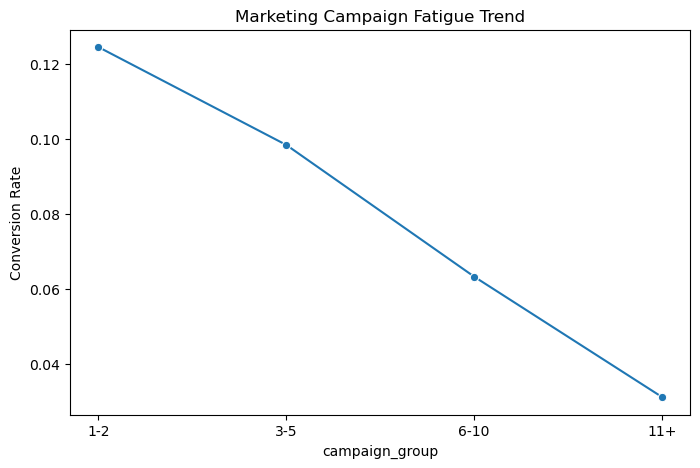

campaign_group
1-2     28202
3-5      9589
6-10     2516
11+       869
Name: count, dtype: int64


In [104]:
# Create bin for more interpretability
df_clean['campaign_group'] = pd.cut(
    df_clean['campaign'],
    bins=[0, 2, 5, 10, 100],
    labels=['1-2', '3-5', '6-10', '11+']
)

# Compute conversion rate
rate = df_clean.groupby('campaign_group', observed=True)['y'].mean().reset_index()

# Plot fatigue chart
plt.figure(figsize=(8,5))
sns.lineplot(x='campaign_group', y='y', data=rate, marker='o')

plt.title('Marketing Campaign Fatigue Trend')
plt.ylabel('Conversion Rate')
plt.show()

# Show sample size of each bin group
counts = df_clean['campaign_group'].value_counts().sort_index()

print(counts)

Interpretation: Conversion rates decrease as the number of contact attempts increases, indicating diminishing returns and potential customer fatigue from repeated calls.

## 5. Previous Campaign Outcome Conversion Rate

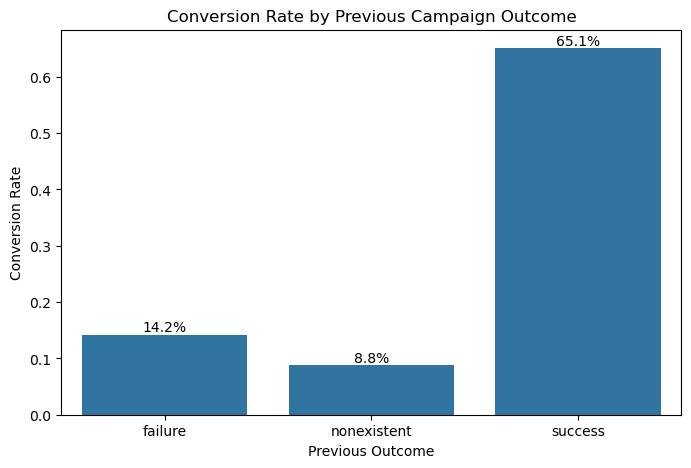

poutcome
nonexistent    35551
failure         4252
success         1373
Name: count, dtype: int64


In [105]:
# Compute conversion rate
rate = df_clean.groupby('poutcome')['y'].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
ax = sns.barplot(x='poutcome', y='y', data=rate)

# Add % labels
for i, v in enumerate(rate['y']):
    ax.text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')

plt.title('Conversion Rate by Previous Campaign Outcome')
plt.xlabel('Previous Outcome')
plt.ylabel('Conversion Rate')

plt.show()

# Show sample size
print(df_clean['poutcome'].value_counts())

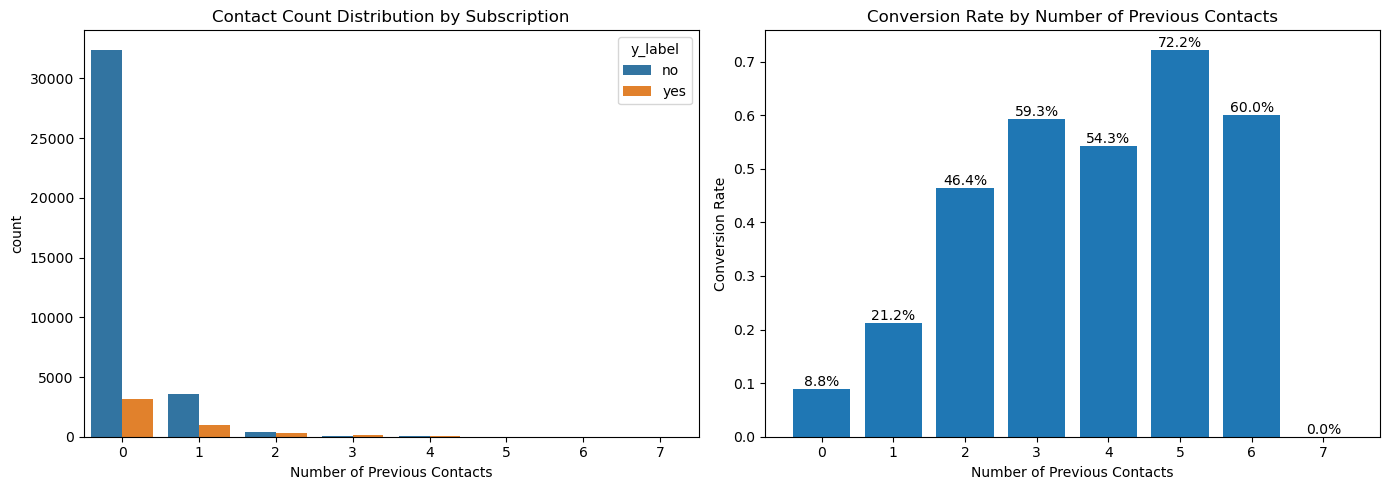

In [106]:
# Compute conversion rate
rate = df_clean.groupby('previous')['y'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sns.countplot(data=df_clean, x='previous', hue='y_label', ax=axes[0])
axes[0].set_title('Contact Count Distribution by Subscription')
axes[0].set_xlabel('Number of Previous Contacts')

# Conversion rate
axes[1].bar(rate['previous'].astype(str), rate['y'])
for i, v in enumerate(rate['y']):
    axes[1].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')
axes[1].set_title('Conversion Rate by Number of Previous Contacts')
axes[1].set_xlabel('Number of Previous Contacts')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

Interpretation: Although the number of people who subscribed to term deposit from previous campaign comparably small, they have really high conversion rate to current campaign as well, especially those who were contacted 3-6 times. This makes them prime targets for future campaigns.

## 6. Duration Feature
We know `duration` causes data leakage but let's see how it matters with our target variable.

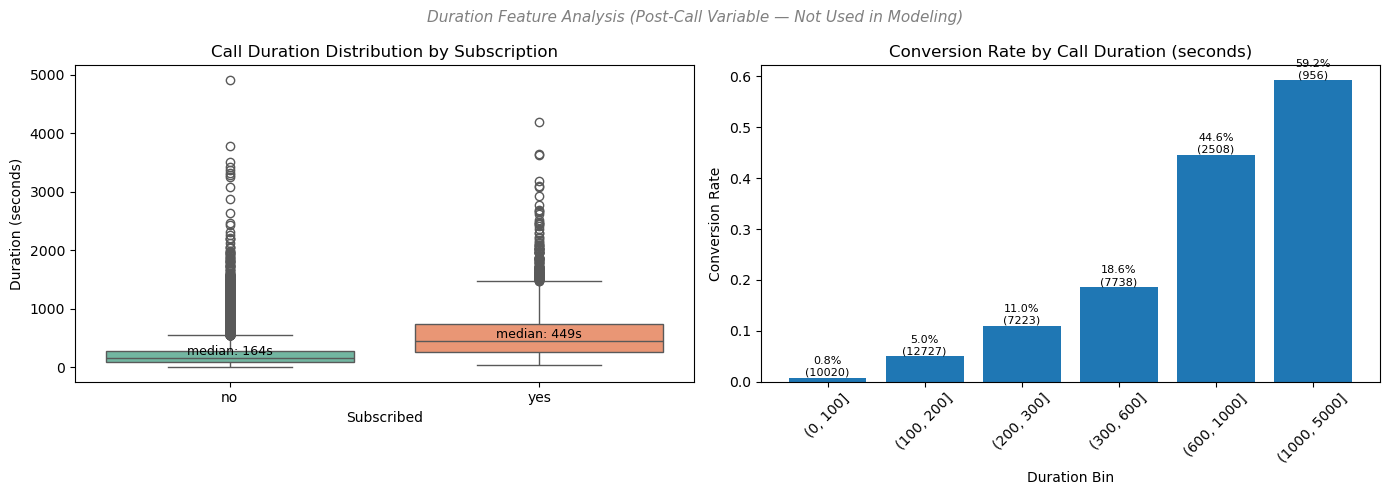

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distribution by subscription
sns.boxplot(data=df_clean, x='y_label', y='duration', ax=axes[0], palette='Set2')
axes[0].set_title('Call Duration Distribution by Subscription')
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Duration (seconds)')

# Add median labels
for i, label in enumerate(['no', 'yes']):
    median = df_clean[df_clean['y_label'] == label]['duration'].median()
    axes[0].text(i, median, f'median: {median:.0f}s', 
                ha='center', va='bottom', fontsize=9)

# Right: Conversion rate by duration bin
df_clean['duration_bin'] = pd.cut(
    df_clean['duration'],
    bins=[0, 100, 200, 300, 600, 1000, 5000]
)
duration_rate = df_clean.groupby('duration_bin', observed=True)['y'].mean()
duration_counts = df_clean.groupby('duration_bin', observed=True)['y'].count()

bars = axes[1].bar(range(len(duration_rate)), duration_rate.values)
axes[1].set_xticks(range(len(duration_rate)))
axes[1].set_xticklabels([str(b) for b in duration_rate.index], rotation=45)
axes[1].set_title('Conversion Rate by Call Duration (seconds)')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xlabel('Duration Bin')

# Add conversion % and sample size labels
for i, (v, n) in enumerate(zip(duration_rate.values, duration_counts.values)):
    axes[1].text(i, v, f'{v*100:.1f}%\n({n})', 
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Duration Feature Analysis (Post-Call Variable — Not Used in Modeling)', 
             fontsize=11, style='italic', color='gray')
plt.tight_layout()
plt.show()

In [108]:
# Display average of duration (in minutes)
avg_duration = df_clean['duration'].mean()
print(f"Average Call Duration: {avg_duration:.2f} seconds ({avg_duration/60:.2f} minutes)")

Average Call Duration: 258.32 seconds (4.31 minutes)


Interpretation: Call duration shows a strong positive relationship with subscription success. The bank made a lot of short, low-quality calls. But, conversion rates increase sharply as call duration increases, with calls longer than 600 seconds achieving significantly higher success rates. However, the majority of calls are short in duration and exhibit very low conversion, suggesting that improving customer engagement during calls may significantly enhance campaign effectiveness.

However, duration is a post-call variable and cannot be used for prediction prior to contact, as it reflects the outcome of the interaction rather than a pre-existing customer characteristic.

**Recommendation:** Improve early-stage engagement to prevent short call drop-offs.

## 7. Correlation Analysis

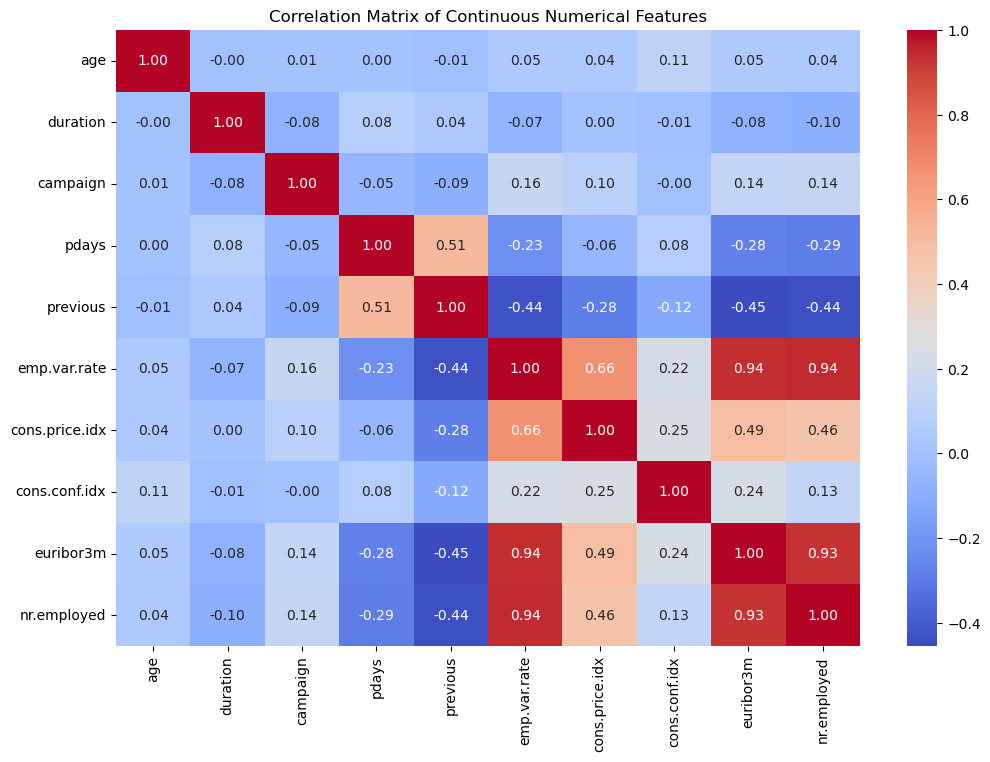

In [109]:
numeric_features = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

plt.figure(figsize=(12, 8))

corr_matrix = df_clean[numeric_features].corr(method='spearman') # Spearman is better for non-linear relationships and outliers, which we have in this dataset

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix of Continuous Numerical Features')
plt.show()

Interpretation: The correlation matrix reveals strong multicollinearity among macroeconomic variables, particularly `emp.var.rate`, `euribor3m`, and `nr.employed`, with correlations **above 0.9**. This indicates that these features capture overlapping economic information and may introduce redundancy in modeling.

In contrast, features such as `age`, `campaign`, and `duration` show low correlation with other variables, indicating they provide more independent information.

## 8. Socio-Economic Impact

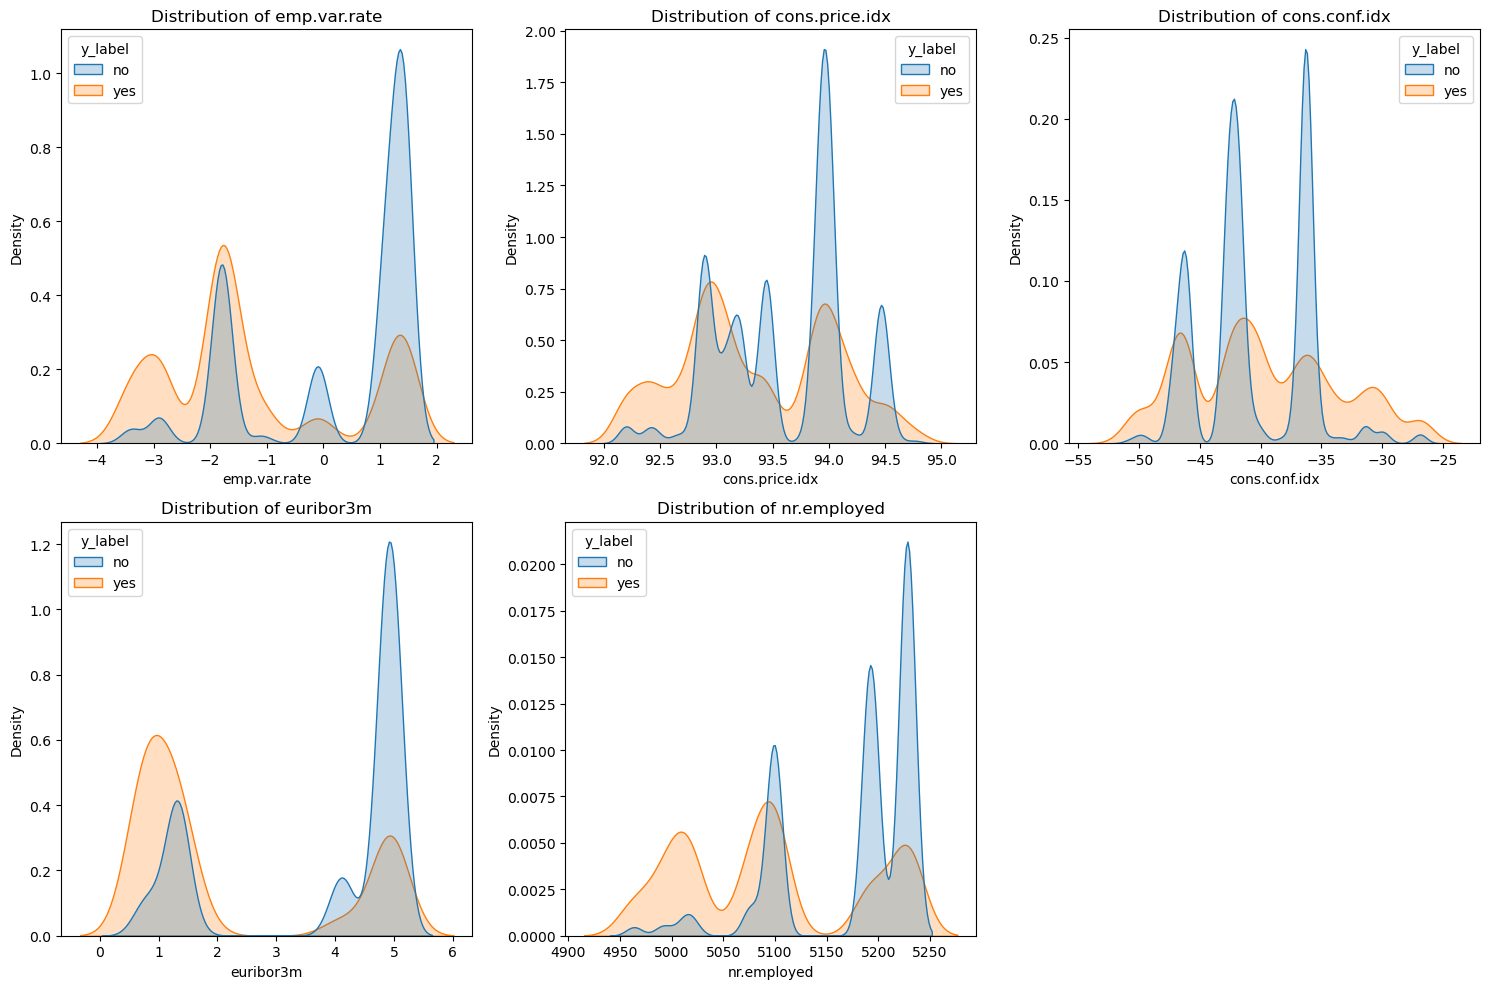

In [110]:
economic_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

plt.figure(figsize=(15, 10))
for i, col in enumerate(economic_cols, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(data=df_clean, x=col, hue='y_label', fill=True, common_norm=False)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

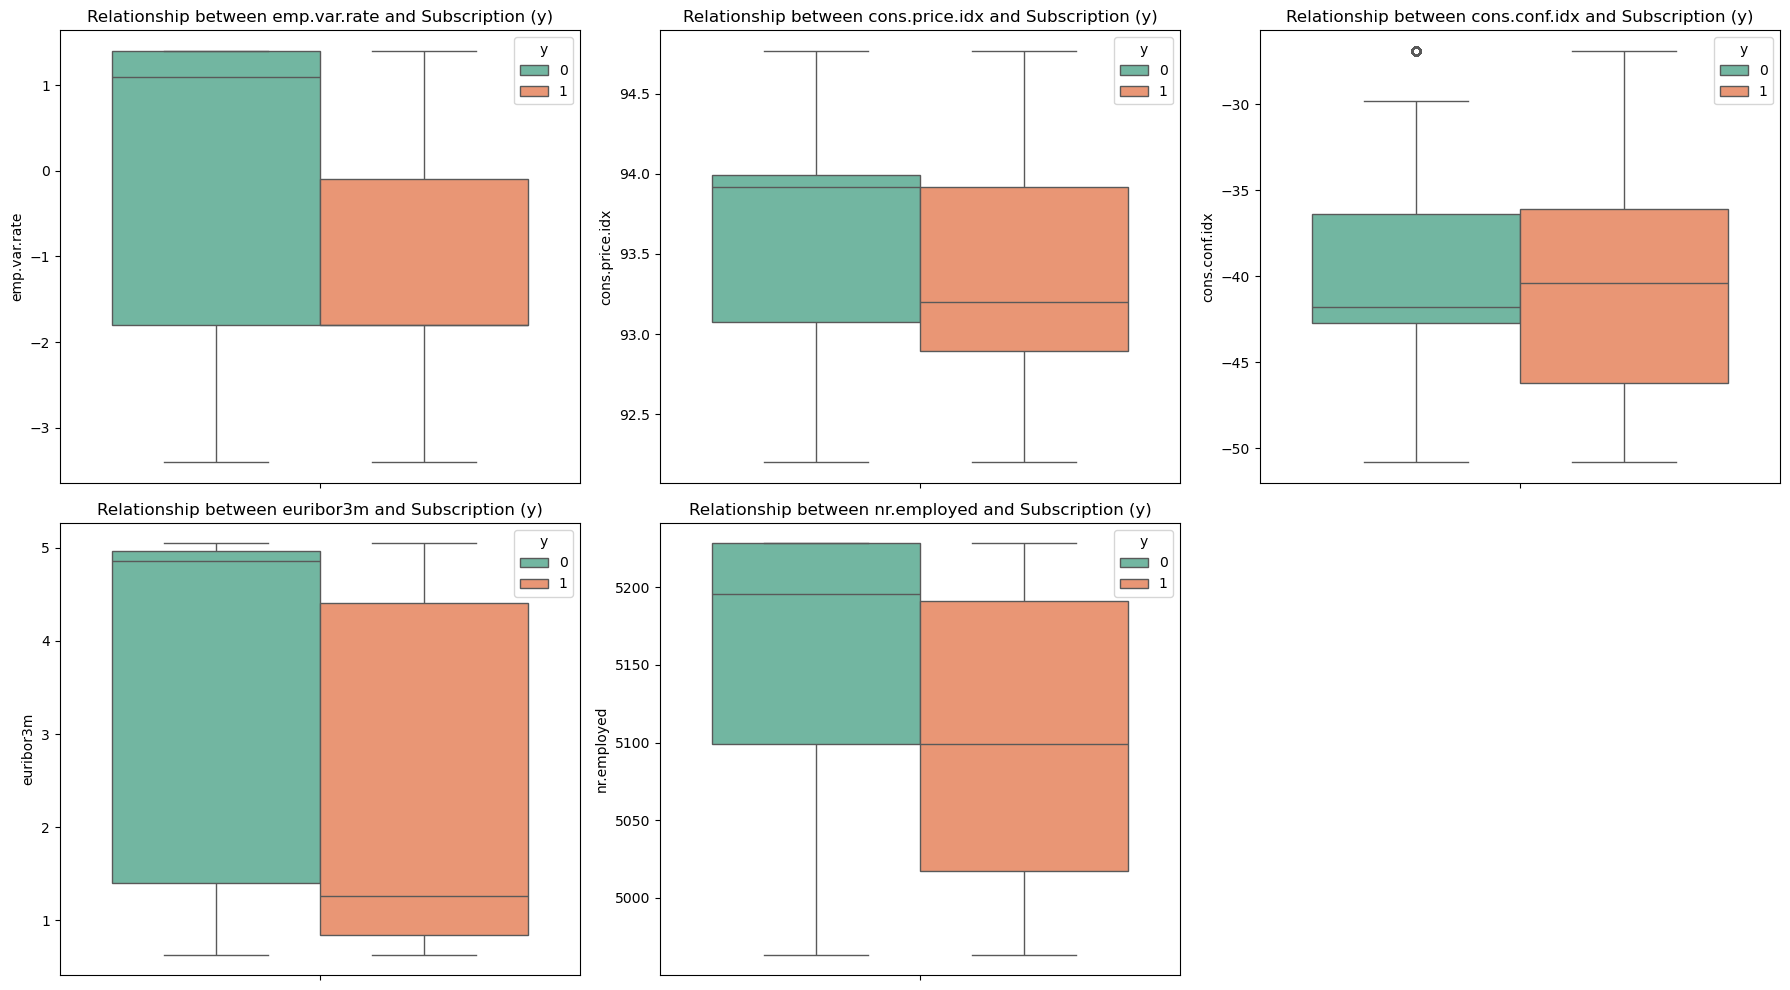

In [111]:
# Function to plot boxplots for socio-economic features
def plot_socio_boxplot(df, features):
    n = len(features)
    cols = 3  # number of plots per row
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 6, rows * 5))

    for i, feature in enumerate(features, 1):
        plt.subplot(rows, cols, i)
        sns.boxplot(hue='y', y=feature, data=df, palette='Set2')
        plt.title(f'Relationship between {feature} and Subscription (y)')
    plt.tight_layout()
    plt.show()

features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
# Plot for Euribor (Interest Rates)
plot_socio_boxplot(df_clean, features)

Interpretation: We found a Counter-Cyclical trend. The bank successfully sold term deposits specifically during economic downturns (Recessions). When the economy was good (High Employment, High Interest Rates), clients were less likely to subscribe. However, when the economy was poor (Negative emp.var.rate, Low nr.employed), clients were more likely to invest in safe term deposits.

**Conclusion:** The "Bad Economy" was actually the "Good Time" for marketing to sell Term Deposits.

## 9. Feature Engineering Validation
With the addition of new features in our feature engineering section, we need to validate whether those key features behave as expected before they go into the model.

### A. Job Category

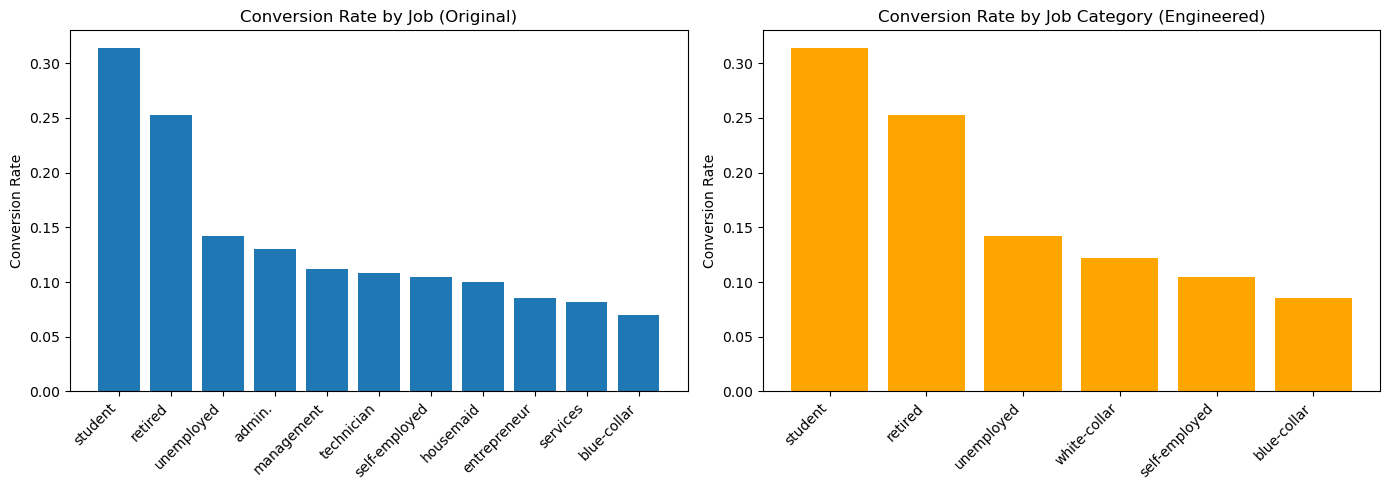

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: job
rate_orig = df_clean.groupby('job')['y'].mean().sort_values(ascending=False)
axes[0].bar(rate_orig.index, rate_orig.values)
axes[0].set_xticklabels(rate_orig.index, rotation=45, ha='right')
axes[0].set_title('Conversion Rate by Job (Original)')
axes[0].set_ylabel('Conversion Rate')

# Engineered: job_category
rate_eng = df_clean.groupby('job_category')['y'].mean().sort_values(ascending=False)
axes[1].bar(rate_eng.index, rate_eng.values, color='orange')
axes[1].set_xticklabels(rate_eng.index, rotation=45, ha='right')
axes[1].set_title('Conversion Rate by Job Category (Engineered)')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

### B. Age Bin

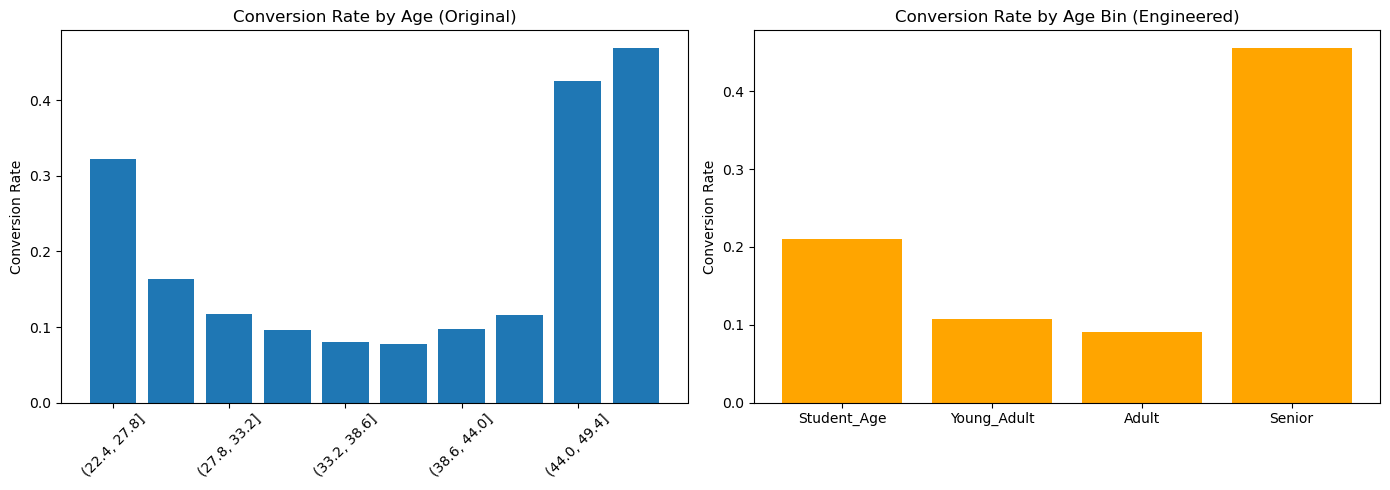

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: age binned manually for conversion rate
age_bins = pd.cut(df_clean['age'], bins=10)
rate_orig = df_clean.groupby(age_bins)['y'].mean()
axes[0].bar(range(len(rate_orig)), rate_orig.values)
axes[0].set_xticklabels([str(i) for i in rate_orig.index], rotation=45)
axes[0].set_title('Conversion Rate by Age (Original)')
axes[0].set_ylabel('Conversion Rate')

# Engineered: age_bin
rate_eng = df_clean.groupby('age_bin', observed=True)['y'].mean()
axes[1].bar(rate_eng.index.astype(str), rate_eng.values, color='orange')
axes[1].set_title('Conversion Rate by Age Bin (Engineered)')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

### C. Education Level

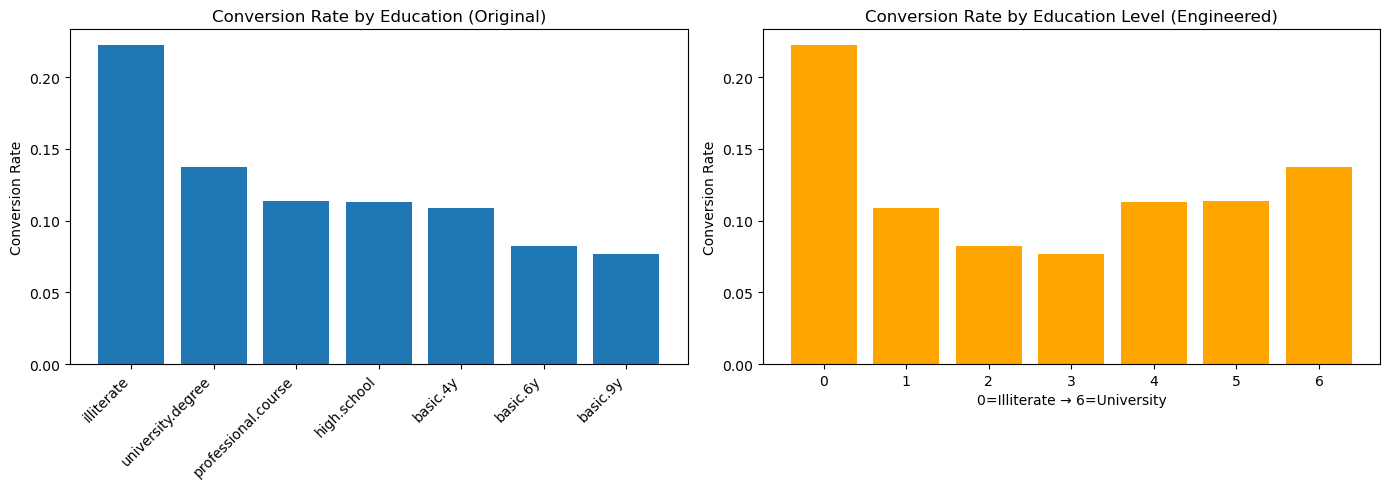

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: education
rate_orig = df_clean.groupby('education')['y'].mean().sort_values(ascending=False)
axes[0].bar(rate_orig.index, rate_orig.values)
axes[0].set_xticklabels(rate_orig.index, rotation=45, ha='right')
axes[0].set_title('Conversion Rate by Education (Original)')
axes[0].set_ylabel('Conversion Rate')

# Engineered: education_level
rate_eng = df_clean.groupby('education_level')['y'].mean().sort_index()
axes[1].bar(rate_eng.index.astype(str), rate_eng.values, color='orange')
axes[1].set_title('Conversion Rate by Education Level (Engineered)')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xlabel('0=Illiterate → 6=University')

plt.tight_layout()
plt.show()

### D. Is Married Group

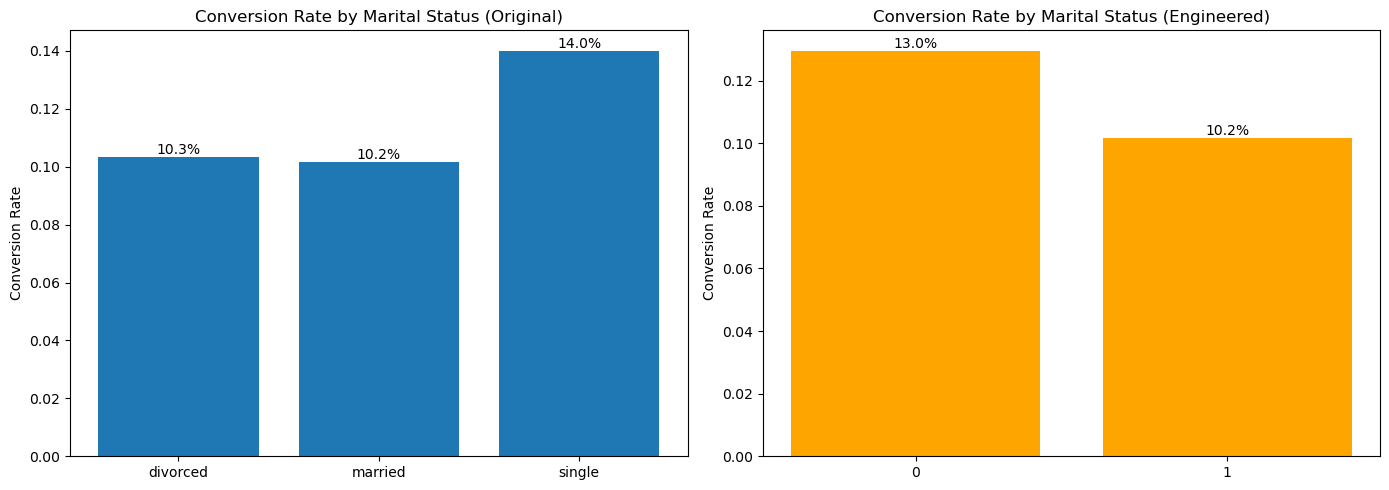

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: marital
rate_orig = df_clean.groupby('marital', observed=True)['y'].mean()
axes[0].bar(rate_orig.index.astype(str), rate_orig.values)
for i, v in enumerate(rate_orig.values):
    axes[0].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')
axes[0].set_title('Conversion Rate by Marital Status (Original)')
axes[0].set_ylabel('Conversion Rate')

# Engineered: is_married
rate_eng = df_clean.groupby('is_married')['y'].mean()
axes[1].bar(rate_eng.index.astype(str), rate_eng.values, color='orange')
for i, v in enumerate(rate_eng.values):
    axes[1].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')
axes[1].set_title('Conversion Rate by Marital Status (Engineered)')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

Interpretation: Because the new feature grouped single with divorced, it does seem like it behaves as expected.

### E. Never Contacted Group

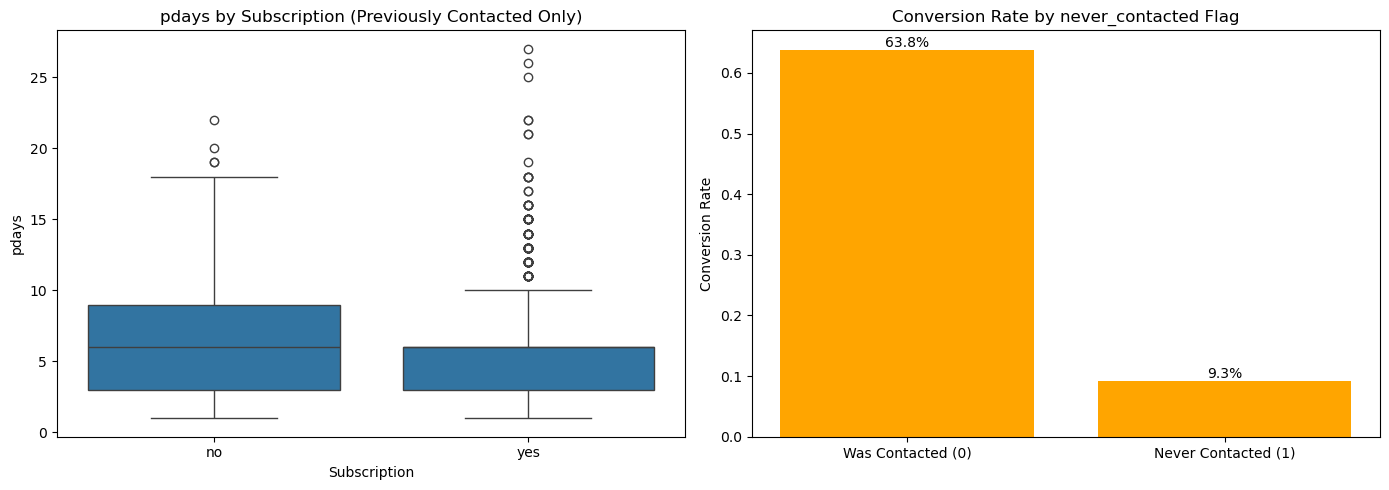

never_contacted
1    39661
0     1515
Name: count, dtype: int64


In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: pdays (exclude never-contacted)
pdays_actual = df_clean[df_clean['pdays'] != 0]

sns.boxplot(data=pdays_actual, x='y_label', y='pdays', ax=axes[0])
axes[0].set_title('pdays by Subscription (Previously Contacted Only)')
axes[0].set_xlabel('Subscription')
axes[0].set_ylabel('pdays')

# Engineered: never_contacted flag
rate_eng = df_clean.groupby('never_contacted')['y'].mean()

axes[1].bar(['Was Contacted (0)', 'Never Contacted (1)'], rate_eng.values, color='orange')
for i, v in enumerate(rate_eng.values):
    axes[1].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')

axes[1].set_title('Conversion Rate by never_contacted Flag')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

print(df_clean['never_contacted'].value_counts())

Interpretation: The left boxplot shows, among actually-contacted people, the "yes" subscribers cluster heavily at **3–6 days after last contact**, suggesting there's an optimal re-contact window. The engineered feature (right chart) is a strong positive signal that clients who were previously reached out to convert at nearly **7x the rate of fresh contacts**.

### F. Campaign Intensity

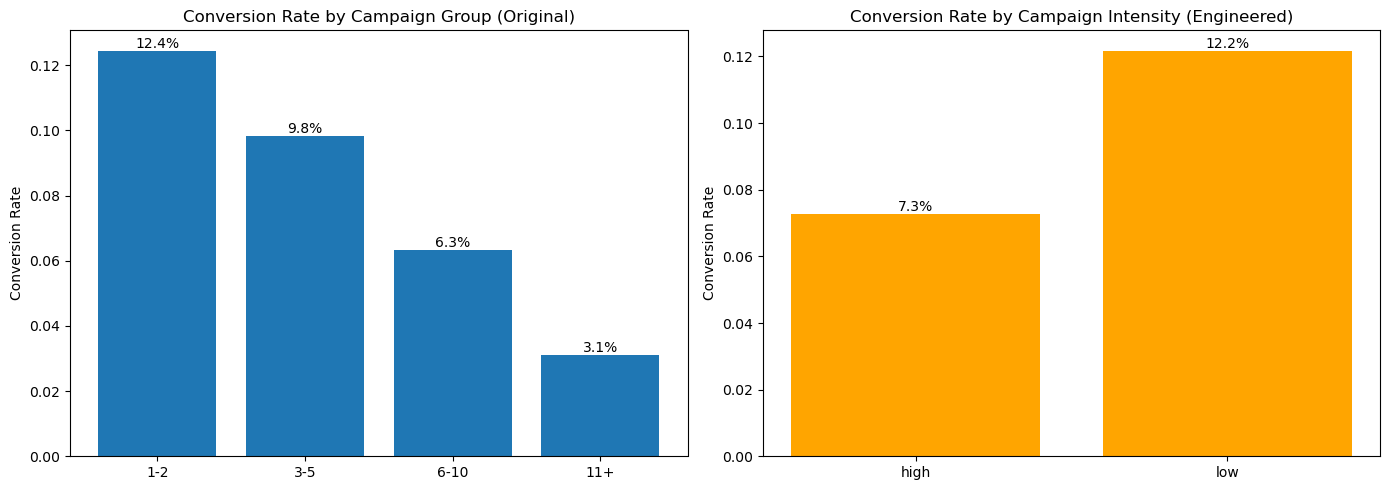

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: already covered in campaign fatigue section — just reference it
rate_orig = df_clean.groupby('campaign_group', observed=True)['y'].mean()
axes[0].bar(rate_orig.index.astype(str), rate_orig.values)
for i, v in enumerate(rate_orig.values):
    axes[0].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')
axes[0].set_title('Conversion Rate by Campaign Group (Original)')
axes[0].set_ylabel('Conversion Rate')

# Engineered: campaign_intensity
rate_eng = df_clean.groupby('campaign_intensity')['y'].mean()
axes[1].bar(rate_eng.index, rate_eng.values, color='orange')
for i, v in enumerate(rate_eng.values):
    axes[1].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')
axes[1].set_title('Conversion Rate by Campaign Intensity (Engineered)')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

Interpretation: Campaign Fatigue already told the story that conversion drops steadily as contact attempts increase. The engineered version (right) cleanly captures this: low intensity (≤3 calls) converts at 12.2% vs high intensity (>3 calls) at 7.3%.

### G. Price_Conf_Index

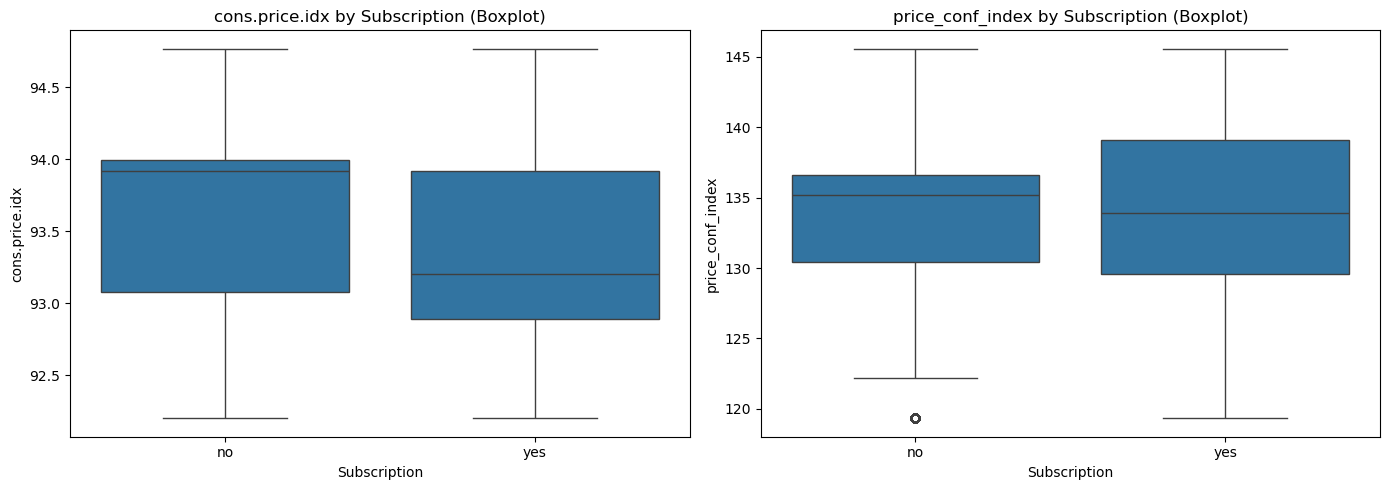

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original feature (cons.price.idx)
sns.boxplot(data=df_clean, x='y_label', y='cons.price.idx', ax=axes[0])
axes[0].set_title('cons.price.idx by Subscription (Boxplot)')
axes[0].set_xlabel('Subscription')
axes[0].set_ylabel('cons.price.idx')

# Engineered feature (price_conf_index)
sns.boxplot(data=df_clean, x='y_label', y='price_conf_index', ax=axes[1])
axes[1].set_title('price_conf_index by Subscription (Boxplot)')
axes[1].set_xlabel('Subscription')
axes[1].set_ylabel('price_conf_index')

plt.tight_layout()
plt.show()

Interpretation: The engineered feature (price_conf_index) shows only marginal improvement in separation between subscribed and non-subscribed compared to its original components (cons.price.idx). The substantial overlap in distributions indicates limited discriminative power. Additionally, given its high correlation with existing socio-economic variables and lack of importance in modeling, the feature is excluded to avoid redundancy.

### H. Economy Growing

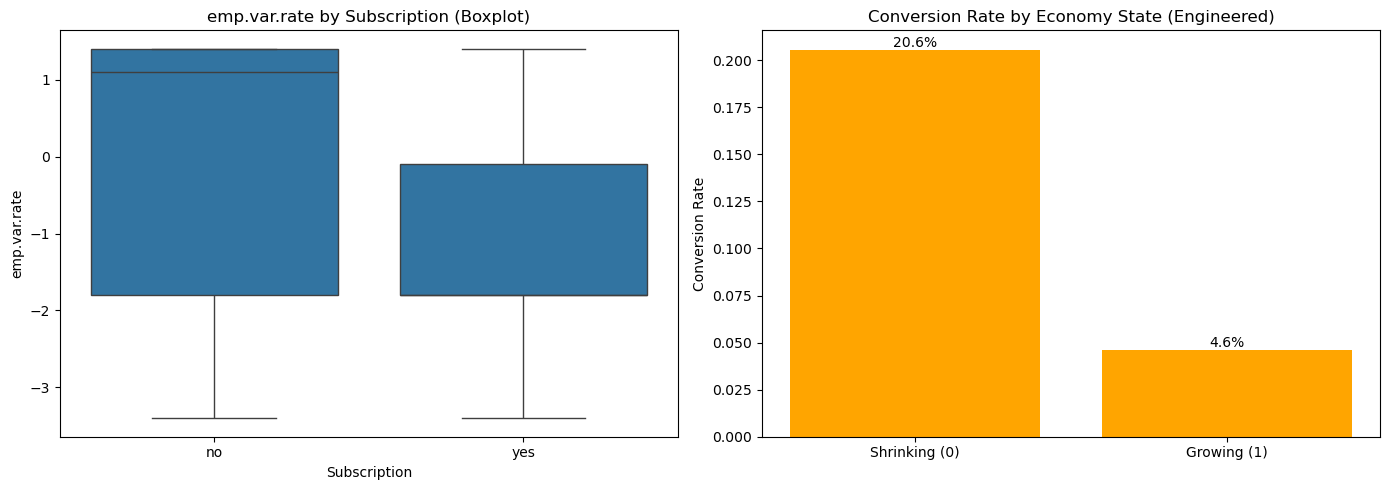

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original: emp.var.rate (BOXPLOT)
sns.boxplot(data=df_clean, x='y_label', y='emp.var.rate', ax=axes[0])
axes[0].set_title('emp.var.rate by Subscription (Boxplot)')
axes[0].set_xlabel('Subscription')
axes[0].set_ylabel('emp.var.rate')

# Engineered: economy_growing (BAR)
rate_eng = df_clean.groupby('economy_growing')['y'].mean()

axes[1].bar(['Shrinking (0)', 'Growing (1)'], rate_eng.values, color='orange')
for i, v in enumerate(rate_eng.values):
    axes[1].text(i, v, f'{v*100:.1f}%', ha='center', va='bottom')

axes[1].set_title('Conversion Rate by Economy State (Engineered)')
axes[1].set_ylabel('Conversion Rate')

plt.tight_layout()
plt.show()

Interpretation: The boxplot shows that "yes" subscribers concentrate heavily the negative side of `emp.var.rate` (shrinking economy). The engineered bar chart confirms this dramatically: shrinking economy converts at 20.6% vs growing economy at only 4.6%, a **4x difference!** This is our counter-cyclical finding from the socio-economic section, now cleanly captured in one binary feature.

# Modeling

## Copy Cleaned Dataset for Modeling

In [120]:
df_model = df_clean.copy()

## Remove Features for Modeling
`duration` feature is removed because it introduces data leakage if used in modeling as in reality duration of a call is not known before a call is made. `y_label` and `campaign_group` were EDA only features. `pdays` is already represented by `never_contacted` and majority of the data was never contacted anyway (~96%). And then, we remove `emp.var.rate` and `nr.employed` because `emp.var.rate`, `euribor3m`, and `nr.employed` are highly correlated as seen in the correlation analysis which introduces multicollinearity. Because the model would just see the same information three times, we choose one feature with the highest correlation with our variable y target and remove the rest. `euribor3m` (Interest Rate) is the one we kept because it's easier to explain: "When interest rates are low, people buy term deposits." 

In [121]:
columns_to_drop = ['duration', 'duration_bin', 'pdays', 'emp.var.rate', 'nr.employed', 'price_conf_index', 'y_label', 'campaign_group']

df_model = df_model.drop(columns=columns_to_drop)

print(f"Original shape: {df_clean.shape}")
print(f"New shape: {df_model.shape}")

Original shape: (41176, 32)
New shape: (41176, 24)


In [122]:
df_model.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,y,job_category,education_level,is_married,age_bin,never_contacted,campaign_intensity,economy_growing
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,0,nonexistent,93.994,-36.4,4.857,0,blue-collar,1,1,Adult,1,low,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,0,nonexistent,93.994,-36.4,4.857,0,blue-collar,4,1,Adult,1,low,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,0,nonexistent,93.994,-36.4,4.857,0,blue-collar,4,1,Young_Adult,1,low,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,0,nonexistent,93.994,-36.4,4.857,0,white-collar,2,1,Young_Adult,1,low,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,0,nonexistent,93.994,-36.4,4.857,0,blue-collar,4,1,Adult,1,low,1


## Train-Test Split

In [123]:
# Split first before scaling to avoid data leakage
X = df_model.drop(columns=['y'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2042, stratify=y  # stratify preserves class ratio
)

## Features Encoding and Scaling

In [124]:
# Define the specific order for your ordinal features
education_order = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 
    'high.school', 'professional.course', 'university.degree', 'unknown'
]

age_bin_order = ['Student_Age', 'Young_Adult', 'Adult', 'Senior']

intensity_order = ['low', 'high']

In [125]:
# Set up ColumnTransformers for both raw and engineered features to compare later in modeling
# Model 1: Raw Features
raw_num = ['age', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']
raw_nom = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
raw_ord = ['education']

preprocessor_raw = ColumnTransformer([
    ('num', StandardScaler(), raw_num),
    ('nom', OneHotEncoder(handle_unknown='ignore'), raw_nom),
    ('ord', OrdinalEncoder(categories=[education_order]), raw_ord)
])

# Model 2: Engineered Features
eng_num = ['campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']
eng_nom = ['job_category', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
eng_ord = ['age_bin', 'campaign_intensity']
eng_num_already = ['education_level', 'is_married', 'never_contacted', 'economy_growing'] # already numeric, just need to be passed through

preprocessor_eng = ColumnTransformer([
    ('num', StandardScaler(), eng_num),
    ('nom', OneHotEncoder(handle_unknown='ignore'), eng_nom),
    ('ord', OrdinalEncoder(categories=[age_bin_order, intensity_order]), eng_ord),
    ('bin', 'passthrough', eng_num_already)
])

## Models

In [126]:
# Models
test_models = [
    ('LogReg', LogisticRegression(max_iter=1000, random_state=2042, class_weight='balanced')),
    ('KNN', KNeighborsClassifier()),
    ('DecisionTree', DecisionTreeClassifier(random_state=2042, class_weight='balanced')),
    ('RandomForest', RandomForestClassifier(n_jobs=-1, random_state=2042, class_weight='balanced')),
    ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=2042)),
    ('LightGBM', lgb.LGBMClassifier(verbosity=-1, random_state=2042))    
]

## Model Benchmark: Cross-Validation
This analysis aims to determine the best model for predicting whether a customer will subscribe to a time deposit (*target: "yes" or "no"*) while also comparing whether to use engineered features or raw features. Due to class imbalance, Stratified 5-fold Cross-Validation and SMOTE (Synthetic Minority Oversampling Technique) are used. Stratified is used to ensure that each fold maintains the same proportion of subscribed (`yes`) and non-subscribed (`no`) customers as the original dataset. By applying SMOTE, which generates synthetic examples of the minority class (`yes`), the model wouldn't be biased toward predicting the majority class (`no`) and better learn patterns associated with potential subscribers. Importantly, SMOTE is applied within pipeline to avoid data leakage and ensure fair model evaluation.

In [127]:
# Metrics
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

# Function for benchmarking models with given preprocessor and data
def get_benchmark_results(name, preprocessor, X, y):
    results = []
    
    print(f"\n🔹 Running Benchmark for: {name} Feature Set\n")
    
    for model_name, model_obj in test_models:

        start_time = time.time() # Start time for the model
        
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=2042)),
            ('classifier', model_obj)
        ])
        
        cv_results = cross_validate(
            pipeline,
            X,
            y,
            cv=skf,
            scoring=scoring_metrics,
            n_jobs=-1,
            error_score='raise'
        )

        elapsed_time = time.time() - start_time # End time for the model
        
        results.append({
            'Feature Set': name,
            'Model': model_name,
            'F1 Score': cv_results['test_f1'].mean(),
            'ROC AUC': cv_results['test_roc_auc'].mean(),
            'Precision': cv_results['test_precision'].mean(),
            'Recall': cv_results['test_recall'].mean(),
            'Accuracy': cv_results['test_accuracy'].mean(),
        })
        
        print(f"Finished {model_name} in {elapsed_time:.2f} seconds")
    
    return results

# Run both feature sets
raw_results = get_benchmark_results("Raw", preprocessor_raw, X_train, y_train)
eng_results = get_benchmark_results("Engineered", preprocessor_eng, X_train, y_train)

# Combine results
df_results = pd.DataFrame(raw_results + eng_results)

# Display sorted
df_results = df_results.sort_values(by='F1 Score', ascending=False)

print("\n--- Model Benchmark Results (Stratified 5-Fold CV + SMOTE) ---")
display(df_results.round(4))


🔹 Running Benchmark for: Raw Feature Set

Finished LogReg in 0.88 seconds
Finished KNN in 3.81 seconds
Finished DecisionTree in 1.03 seconds
Finished RandomForest in 5.46 seconds
Finished XGBoost in 2.77 seconds
Finished LightGBM in 1.97 seconds

🔹 Running Benchmark for: Engineered Feature Set

Finished LogReg in 1.34 seconds
Finished KNN in 3.91 seconds
Finished DecisionTree in 1.11 seconds
Finished RandomForest in 5.09 seconds
Finished XGBoost in 2.90 seconds
Finished LightGBM in 2.47 seconds

--- Model Benchmark Results (Stratified 5-Fold CV + SMOTE) ---


,Feature Set,Model,F1 Score,ROC AUC,Precision,Recall,Accuracy
6,Engineered,LogReg,0.4356,0.7922,0.3277,0.6497,0.8104
0,Raw,LogReg,0.4316,0.7896,0.3235,0.6486,0.8076
11,Engineered,LightGBM,0.4284,0.7980,0.5865,0.3376,0.8986
5,Raw,LightGBM,0.4254,0.7957,0.5768,0.3374,0.8974
3,Raw,RandomForest,0.4187,0.7733,0.4995,0.3606,0.8872
10,Engineered,XGBoost,0.4166,0.7876,0.5727,0.3274,0.8967
9,Engineered,RandomForest,0.4053,0.7625,0.4687,0.3573,0.8819
4,Raw,XGBoost,0.4051,0.7843,0.5669,0.3153,0.8957
7,Engineered,KNN,0.3559,0.7238,0.2562,0.5831,0.7622
1,Raw,KNN,0.3487,0.7214,0.2447,0.6071,0.7445


Interpretation:
- Engineered Logistic Regression has the highest **F1-Score** ($0.4356$) and **Recall** ($0.6497$) which means if the bank's goal is to **attract as many customers as possible** regardless of calls made, these two should be considered. Logistic Regression in particular is able to capture 64% of the total customers who were actually willing to subscribe.
- Engineered LightGBM dominates in **ROC-AUC** ($0.798$) and **Precision** ($0.5865$). If the bank wants to run a highly efficient campaign with low operational costs, LightGBM would be the choce. With a Precision of ~0.58, the model is able to predict 58% of successful subscription from all predicted result.
- All the top models (LGBM, XGB, LogReg) have **ROC-AUC** scores around **0.79** (pretty good discrimination), which means they were able to distinguish between customers who will say "Yes" and "No".
- Comparing engineered features and raw features, models with engineered features overall have better score and faster. This meant the features successfully simplify but preserved and improved information in the dataset for the model to learn.

## Model Benchmark: Test Data
After performing cross-validation benchmarking, the models must be further evaluated on a held-out test dataset to assess their real-world performance.

While cross-validation provides a robust estimate of model performance, it still uses only the training data (split into folds). Therefore, in this section each model will be trained on a training set and then evaluated on the test set which was done from Train-Test Split.

SMOTE is also applied within pipeline to handle class imbalance and prevent it from touching the test data.

In [128]:
# Function for test evaluation
def get_test_results(name, preprocessor, X_train, y_train, X_test, y_test):
    warnings.filterwarnings('ignore', category=UserWarning)
    results = []
    
    print(f"\n🔹 Running Test Evaluation for: {name} Feature Set\n")
    
    for model_name, model_obj in test_models:
        
        start_time = time.time()
        
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=2042)),
            ('classifier', model_obj)
        ])
        
        # Train on full training data
        pipeline.fit(X_train, y_train)
        
        # Predict on test data
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        elapsed_time = time.time() - start_time
        
        # Store results
        results.append({
            'Feature Set': name,
            'Model': model_name,
            'F1 Score': f1_score(y_test, y_pred),
            'ROC AUC': roc_auc_score(y_test, y_proba),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'Accuracy': (y_pred == y_test).mean()
        })

        print(f"Finished {model_name} in {elapsed_time:.2f} seconds")
    
    return results


# Run test evaluation
raw_test_results = get_test_results("Raw", preprocessor_raw, X_train, y_train, X_test, y_test)
eng_test_results = get_test_results("Engineered", preprocessor_eng, X_train, y_train, X_test, y_test)

# Combine results
df_test_results = pd.DataFrame(raw_test_results + eng_test_results)

# Sort by F1 Score
df_test_results = df_test_results.sort_values(by='F1 Score', ascending=False)

print("\n--- Final Test Set Results ---")
display(df_test_results.round(4))


🔹 Running Test Evaluation for: Raw Feature Set

Finished LogReg in 0.36 seconds
Finished KNN in 1.21 seconds
Finished DecisionTree in 0.82 seconds
Finished RandomForest in 1.54 seconds
Finished XGBoost in 0.83 seconds
Finished LightGBM in 0.74 seconds

🔹 Running Test Evaluation for: Engineered Feature Set

Finished LogReg in 0.61 seconds
Finished KNN in 1.36 seconds
Finished DecisionTree in 0.80 seconds
Finished RandomForest in 1.44 seconds
Finished XGBoost in 0.78 seconds
Finished LightGBM in 0.66 seconds

--- Final Test Set Results ---


,Feature Set,Model,F1 Score,ROC AUC,Precision,Recall,Accuracy
11,Engineered,LightGBM,0.4270,0.7846,0.5604,0.3448,0.8957
6,Engineered,LogReg,0.4139,0.7755,0.3086,0.6282,0.7995
5,Raw,LightGBM,0.4106,0.7778,0.5562,0.3254,0.8947
10,Engineered,XGBoost,0.4104,0.7750,0.5652,0.3222,0.8957
0,Raw,LogReg,0.4077,0.7734,0.3028,0.6239,0.7958
4,Raw,XGBoost,0.4025,0.7661,0.5483,0.3179,0.8936
3,Raw,RandomForest,0.4020,0.7597,0.4798,0.3459,0.8840
9,Engineered,RandomForest,0.3920,0.7571,0.4503,0.3470,0.8787
7,Engineered,KNN,0.3516,0.7090,0.2552,0.5647,0.7653
8,Engineered,DecisionTree,0.3437,0.6386,0.3307,0.3578,0.8460


Interpretation:
- Engineered **LightGBM (F1-Score = $0.427$)** outperformed other models on the test set, surpassing Engineered Logistic Regression (F1-Score = $0.4136$), while also maintaining the highest **ROC-AUC ($0.7846$)**.
- Engineered Logistic Regression still achieved the highest **Recall ($0.6282$)**, although slightly lower than its cross-validation performance ($0.6497$), indicating minor optimism during CV.
- Engineered **XGBoost** achieved the highest **Precision ($0.5652$)**, but only marginally higher than LightGBM ($0.5604$). LightGBM remains competitive in precision while offering better overall balance.
- All top models (LightGBM, Logistic Regression, XGBoost) show consistent **ROC-AUC scores (~0.77-0.78)** between cross-validation and test results, suggesting good generalization and low risk of overfitting.

Conclusion:
Model selection should be aligned with the bank's business priorities:
* **Increase Conversion Rate (Recall-focused):** Use **Logistic Regression** if the goal is to identify as many potential subscribers as possible. Its high recall ensures fewer missed opportunities, though at the cost of more unnecessary calls.
* **Cost Optimization (Precision + Balance)**: Use **LightGBM** if the goal is to reduce wasted calls and improve campaign efficiency. While its precision is slightly lower than XGBoost, it provides a better overall balance through higher F1-score, strong ROC-AUC, and stable performance across validation and test sets.

## Resampling
Now that we've got two promising models, we can try evaluate using four distinct resampling strategies to find the optimal decision boundary:
* **Random Oversampling (ROS):** Augments the minority class by duplicating existing 'Yes' samples. This is effective for reinforcing existing patterns but carries a slight risk of overfitting.
* **Random Undersampling (RUS):** Balances the dataset by removing majority class samples. While efficient, it risks discarding potentially valuable information from the 'No' class.
* **SMOTE (Synthetic Minority Over-sampling Technique):** Generates synthetic 'Yes' samples by interpolating between existing minority points, creating a more generalized decision region.
* **Hybrid (SMOTETomek):** A sophisticated two-step approach that applies SMOTE to create synthetic samples and then uses Tomek Links to remove "noisy" or overlapping samples near the class borders. This often results in a cleaner, more defined separation between classes.

In [129]:
# Define the Resamplers
resamplers = [
    ('SMOTE', SMOTE(random_state=2042)),
    ('Oversampling', RandomOverSampler(random_state=2042)),
    ('Undersampling', RandomUnderSampler(random_state=2042)),
    ('Hybrid_SMOTE_Tomek', SMOTETomek(random_state=2042))
]

# Define the Models (Using our two best performers)
models_to_test = [
    ('LogReg', LogisticRegression(max_iter=1000, random_state=2042)),
    ('LightGBM', lgb.LGBMClassifier(verbosity=-1, random_state=2042))
]

# The Comparison Loop
resampling_results = []

for res_name, res_obj in resamplers:
    for mod_name, mod_obj in models_to_test:
        
        # Build the pipeline: Preprocess -> Resample -> Model
        # Note: We use the Engineered Preprocessor here as it won the last test
        test_pipe = ImbPipeline([
            ('prep', preprocessor_eng),
            ('resample', res_obj),
            ('classifier', mod_obj)
        ])
        
        # Cross-validate
        cv = cross_validate(test_pipe, X_train, y_train, cv=skf,
                            scoring=scoring_metrics, n_jobs=-1, error_score='raise')
        
        resampling_results.append({
            'Resampler': res_name,
            'Model': mod_name,
            'F1 Score': cv['test_f1'].mean(),
            'ROC AUC': cv['test_roc_auc'].mean(),
            'Precision': cv['test_precision'].mean(),
            'Recall': cv['test_recall'].mean(),
            'Accuracy': cv['test_accuracy'].mean(),
        })

# Display Results
df_resampling = pd.DataFrame(resampling_results)

# Sort by F1 Score
df_resampling = df_resampling.sort_values(by='F1 Score', ascending=False)

print("\n--- Resampling Results ---")
display(df_resampling.round(4))


--- Resampling Results ---


,Resampler,Model,F1 Score,ROC AUC,Precision,Recall,Accuracy
3,Oversampling,LightGBM,0.4722,0.8030,0.3747,0.6389,0.8391
2,Oversampling,LogReg,0.4452,0.7946,0.3383,0.6513,0.8171
5,Undersampling,LightGBM,0.4432,0.7959,0.3351,0.6553,0.8142
4,Undersampling,LogReg,0.4402,0.7933,0.3320,0.6532,0.8128
6,Hybrid_SMOTE_Tomek,LogReg,0.4358,0.7923,0.3278,0.6502,0.8104
0,SMOTE,LogReg,0.4356,0.7922,0.3277,0.6497,0.8104
7,Hybrid_SMOTE_Tomek,LightGBM,0.4306,0.7976,0.5837,0.3414,0.8984
1,SMOTE,LightGBM,0.4284,0.7980,0.5865,0.3376,0.8986


Interpretation: Upon comparing the resampling techniques, **Random Oversampling** paired with **LightGBM** emerged as the superior configuration, achieving the highest F1-Score (**0.4722**) and ROC AUC (**0.803**). **Logistic Regression** paired with **Random Oversampling** also achieved relatively high score just before LightGBM but it has higher Recall (**0.6513**).

### Resampling with ROS
Since we found Random Oversampling to be the superior pair with the model, let's see if we can find a better ratio than the default 50:50.

In [130]:
# Create a pipeline for LightGBM and Logistic Regression with ROS
# LightGBM pipeline
pipe_lgbm_ros = ImbPipeline([
    ('preprocessor', preprocessor_eng),
    ('resample', RandomOverSampler(random_state=2042)),
    ('classifier', lgb.LGBMClassifier(verbosity=-1, random_state=2042))
])

# Logistic Regression pipeline
pipe_logreg_ros = ImbPipeline([
    ('preprocessor', preprocessor_eng),
    ('resample', RandomOverSampler(random_state=2042)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=2042))
])

# Define the ratios to test
# 0.2 means 'Yes' will be 20% of 'No'
# 0.5 means 'Yes' will be 50% of 'No'
param_grid = {
    'resample__sampling_strategy': [0.2, 0.3, 0.4, 0.5, 'auto'] 
}

# Grid Search for LightGBM
grid_search_lgbm_ros = GridSearchCV(pipe_lgbm_ros, param_grid, cv=skf, scoring='f1')
grid_search_lgbm_ros.fit(X_train, y_train)

# Grid Search for Logistic Regression
grid_search_logreg_ros = GridSearchCV(pipe_logreg_ros, param_grid, cv=skf, scoring='f1')
grid_search_logreg_ros.fit(X_train, y_train)

print(f"LightGBM ROS Best Ratio: {grid_search_lgbm_ros.best_params_}")
print(f"Logistic Regression ROS Best Ratio: {grid_search_logreg_ros.best_params_}")

LightGBM ROS Best Ratio: {'resample__sampling_strategy': 0.5}
Logistic Regression ROS Best Ratio: {'resample__sampling_strategy': 0.5}


Interpretation: Both models peaked at a 0.5 ratio, meaning they see one "Yes" for every two "No" cases, which is enough to boost its pattern learning but not too much it becomes "delusional". So this ratio provides enough minority signal to improve **Recall** without causing **Precision** to collapse.

### Resampling with RUS
We also try a bit with Random Undersampling as it may remove redundancy of learning what all "No" looks like when only a some are needed, which also causes the "Yes" cases to stand out more. RUS also reduces the size of training set which helps the model becomes faster and cheaper to run.

In [131]:
from imblearn.under_sampling import RandomUnderSampler

# LightGBM with Random UnderSampling
pipe_lgbm_rus = ImbPipeline([
    ('preprocessor', preprocessor_eng),
    ('resample', RandomUnderSampler(random_state=2042)),
    ('classifier', lgb.LGBMClassifier(verbosity=-1, random_state=2042))
])

# Logistic Regression with Random UnderSampling
pipe_logreg_rus = ImbPipeline([
    ('preprocessor', preprocessor_eng),
    ('resample', RandomUnderSampler(random_state=2042)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=2042))
])

# Grid Search for LightGBM
grid_search_lgbm_rus = GridSearchCV(pipe_lgbm_rus, param_grid, cv=skf, scoring='f1')
grid_search_lgbm_rus.fit(X_train, y_train)

# Grid Search for Logistic Regression
grid_search_logreg_rus = GridSearchCV(pipe_logreg_rus, param_grid, cv=skf, scoring='f1')
grid_search_logreg_rus.fit(X_train, y_train)

print(f"LightGBM RUS Best Ratio: {grid_search_lgbm_rus.best_params_}")
print(f"Logistic Regression RUS Best Ratio: {grid_search_logreg_rus.best_params_}")

LightGBM RUS Best Ratio: {'resample__sampling_strategy': 0.4}
Logistic Regression RUS Best Ratio: {'resample__sampling_strategy': 0.5}


### Results for ROS and RUS

In [132]:
# Display ROS and RUS F1 scores side by side for LightGBM
results_comparison = pd.DataFrame({
    'Model': ['LightGBM', 'Logistic Regression'],
    'ROS': [grid_search_lgbm_ros.best_score_, grid_search_logreg_ros.best_score_],
    'RUS': [grid_search_lgbm_rus.best_score_, grid_search_logreg_rus.best_score_]
})
display(results_comparison.round(4))

,Model,ROS,RUS
0,LightGBM,0.5068,0.5003
1,Logistic Regression,0.4911,0.4894


Interpretation:
* Both LightGBM and Logistic Regression achieve their highest F1-Scores using **Random Oversampling (ROS)**. The fact that ROS outperforms RUS across the board indicates that the majority class ("No") contains non-redundant information. Deleting these samples via Undersampling likely removed nuanced patterns that the models needed to distinguish between 'Yes' and 'No' customers.
* With a peak F1-Score of **0.5068**, the **LightGBM + ROS (0.5 ratio)** configuration is confirmed as our 'Champion Model.'

In [133]:
# Extracting the best models with the optimal ratios
lgbm_model_ros = grid_search_lgbm_ros.best_estimator_
logreg_model_ros = grid_search_logreg_ros.best_estimator_

# Double check that they are using the 0.5 ratio
print(f"LGBM Resampler Ratio: {lgbm_model_ros.named_steps['resample'].sampling_strategy}")
print(f"LogReg Resampler Ratio: {logreg_model_ros.named_steps['resample'].sampling_strategy}")

LGBM Resampler Ratio: 0.5
LogReg Resampler Ratio: 0.5


## Cost-Benefit Analysis
A cost-benefit analysis is conducted to translate model performance into business value. By assigning monetary values to true positives, false positives, and false negatives, we evaluate which model maximizes net profit rather than relying solely on statistical metrics.

Based on the Portuguese banking context, let’s set some "Business Logic" constants:

* Cost per call (C_call): If a call center agent in Portugal earns around €1,900 per month and they do 15 calls/hour, a pure labor cost per call would be ~€0.72 per call. With addition of office space, computers, electricity, etc. which typically double or triple the pure salary cost then our final cost per call is: **€2–3 per call**.
* Revenue per successful subscription (R_subscribe): A typical customer in Portugal deposits around €5,000 in a term deposit. With a 1% net profit spread from the bank, the number would be: **€50 profit per customer per year**.

Keep in mind that all of these very conservative in numbers.

| Confusion Matrix Cell | What It Means | Business Cost |
| :--- | :--- | :--- |
| True Positive (TP) | Predicted yes, actually yes | +€50 revenue − €3 call cost = +€47 net |
| True Negative (TN) | Predicted no, actually no | €0 (correctly skipped) |
| False Positive (FP) | Predicted yes, actually no | -€3 wasted call cost |
| False Negative (FN) | Predicted no, actually yes | -€50 missed revenue opportunity |

Objective: We want a model that maximizes Revenue while minimizing Wasted Costs. Even if a model has more "wasted calls," it might be more beneficial if it misses fewer customers.

In [134]:
# Generate predictions for the test set using the best LightGBM model
y_pred_lgbm = lgbm_model_ros.predict(X_test)

In [135]:
# Define cost assumptions (in euros)
COST_PER_CALL = 3       # cost of one call (FP)
REVENUE_PER_SUB = 50    # net revenue from one successful subscription (TP)

def calculate_business_value(y_test, y_pred, cost_per_call=COST_PER_CALL, 
                              revenue_per_sub=REVENUE_PER_SUB, verbose=True):
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    value_tp = tp * (revenue_per_sub - cost_per_call)  # successful calls
    cost_fp  = fp * cost_per_call                       # wasted calls
    cost_fn  = fn * revenue_per_sub                     # missed opportunities
    
    net_value = value_tp - cost_fp - cost_fn
    baseline = (
    (tp + fn) * (revenue_per_sub - cost_per_call)  # all real positives
    - (fp + tn) * cost_per_call                   # all real negatives also called
    )
    
    if verbose:
        print(f"TP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}")
        print(f"Revenue from correct predictions : +€{value_tp:,.0f}")
        print(f"Cost of wasted calls (FP)        : -€{cost_fp:,.0f}")
        print(f"Missed opportunity cost (FN)     : -€{cost_fn:,.0f}")
        print(f"Net Business Value               :  €{net_value:,.0f}")
        print(f"Baseline                         :  €{baseline:,.0f}")
        print(f"Value added by model             :  €{net_value - baseline:,.0f}")
    
    return net_value

In [136]:
# Calculate business value for the best LightGBM model
print("\n🔹 LightGBM Business Value")
value_lgbm = calculate_business_value(y_test, y_pred_lgbm)


🔹 LightGBM Business Value
TP: 499 | FP: 676 | FN: 429 | TN: 6632
Revenue from correct predictions : +€23,453
Cost of wasted calls (FP)        : -€2,028
Missed opportunity cost (FN)     : -€21,450
Net Business Value               :  €-25
Baseline                         :  €21,692
Value added by model             :  €-21,717


Interpretation: The Cost-Benefit Analysis shows that **LightGBM** generates more profit from prioritizing Recall but still has €-25 net business value which means it's still beat by strategy of "Calling Everyone".

## Threshold Tuning

In [137]:
# Get probabilities for our champion model (LGBM + ROS 0.5)
y_probs = lgbm_model_ros.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0, 0.2, 100)
net_values = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    # We use your function to get the net_value
    val = calculate_business_value(y_test, y_pred_t, verbose=False)
    net_values.append(val)

# Find the optimal point
best_idx = np.argmax(net_values)
best_threshold = thresholds[best_idx]
max_value = net_values[best_idx]

print(f"--- OPTIMIZATION RESULT ---")
print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Max Business Value: €{max_value:,.0f}")

--- OPTIMIZATION RESULT ---
Optimal Threshold: 0.01
Max Business Value: €21,731


Interpretation:

| Metric | Baseline (Call All) | Initial ML (Thresh 0.5) | Optimized ML (Thresh 0.01) |
| :--- | :--- | :--- | :--- |
| **Net Profit** | €21,692 | -€25 | **€21,731** |
| **Value Added** | €0 (Reference) | -€21,717 | **+€39** |

**Key Findings:**
* **Optimal Threshold:** 0.01
* **Strategic Shift:** Because the cost of a wasted call (€3) is significantly lower than the revenue of a subscription (€50), the optimal strategy is to be highly aggressive. 
* **Impact:** By lowering the threshold to 0.01, we capture nearly all potential subscribers. This shift turned a net-loss model into a profit-generating tool that outperforms the 'Call Everyone' baseline.

**Conclusion:** While the bank's default strategy of calling everyone is highly profitable due to the low cost of calls, our **Optimized LightGBM** model provides a slight financial edge by filtering out the 'unreachable' leads. In a real-world scenario with a database of 1,000,000 leads, this 'small' improvement would translate to an additional **€39,000** in profit with significantly fewer man-hours spent on calls.

## Hyperparameter Tuning
While the initial LightGBM model provided a strong baseline, we utilized **RandomizedSearchCV** to refine its architecture. This stage was critical for sharpening the model's "discrimination power," allowing it to better separate potential subscribers from uninterested leads.

In [138]:
# Create the pipeline for LightGBM with ROS 0.5 and set it up for hyperparameter tuning
pipe_lgbm_final = ImbPipeline([
    ('preprocessor', preprocessor_eng),
    ('resample', RandomOverSampler(sampling_strategy=0.5, random_state=2042)), # Fixed at 0.5
    ('classifier', lgb.LGBMClassifier(verbosity=-1, random_state=2042))
])

# Define the parameter space
param_dist = {
    'classifier__n_estimators': [100, 500, 1000],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__num_leaves': [20, 31, 50, 100],
    'classifier__max_depth': [-1, 10, 20, 30],
    'classifier__min_child_samples': [10, 20, 50],
    'classifier__reg_alpha': [0, 0.1, 0.5],
    'classifier__reg_lambda': [0, 0.1, 0.5]
}

# Randomized Search with Stratified K-Fold CV
tuned_search = RandomizedSearchCV(
    pipe_lgbm_final, # Final model
    param_distributions=param_dist,
    n_iter=15, # Try 15 different random combinations
    cv=skf,    # Using shuffled StratifiedKFold
    scoring='f1',
    random_state=2042,
    n_jobs=-1
)

tuned_search.fit(X_train, y_train)

print(f"Best Params: {tuned_search.best_params_}")
print(f"Best F1 Score: {tuned_search.best_score_:.4f}")

Best Params: {'classifier__reg_lambda': 0.1, 'classifier__reg_alpha': 0.5, 'classifier__num_leaves': 31, 'classifier__n_estimators': 100, 'classifier__min_child_samples': 20, 'classifier__max_depth': 20, 'classifier__learning_rate': 0.05}
Best F1 Score: 0.5109


Interpretation: Our model has reached a new best **F1 Score of 0.5109**. Let's see if this new tuned model is "smarter" to allow us to be less "aggressive" and more "surgical" with out calls.

In [139]:
# Extracting the tuned model
tuned_lgbm = tuned_search.best_estimator_
y_probs_tuned = tuned_lgbm.predict_proba(X_test)[:, 1]

# Re-run the profit loop (using cost-benefit business logic)
thresholds = np.linspace(0, 1, 100)
final_profits = []

for t in thresholds:
    y_pred_t = (y_probs_tuned >= t).astype(int)
    val = calculate_business_value(y_test, y_pred_t, verbose=False)
    final_profits.append(val)

best_t_final = thresholds[np.argmax(final_profits)]
max_p_final = max(final_profits)
print(f"--- FINAL RESULT ---")
print(f"Final Optimal Threshold: {best_t_final:.2f}")
print(f"Final Maximum Profit: €{max_p_final:,}")

--- FINAL RESULT ---
Final Optimal Threshold: 0.04
Final Maximum Profit: €21,734


Interpretation:

While our 'Optimized' model identified a threshold of **0.04** for Maximum Profit, this still results in a high volume of False Positives (unsuccessful calls). 

* **Why?** In a vacuum, the €50/€3 ratio justifies an aggressive 'call almost everyone' strategy. 
* **Consequence:** This strategy leads to agent fatigue and potential customer dissatisfaction.

## Strategic Recommendation: Precision-Targeted Outreach
To satisfy the project goal of **Cost Optimization**, we could move the threshold to a point where Precision meets a minimum acceptable level (e.g., 30%), even if it means sacrificing some top-line revenue. This demonstrates a balance between 'Mathematical Optimality' and 'Operational Sustainability.'

In [140]:
# Calculate Precision and Recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_tuned)

# Find the threshold where precision first hits 30% (0.30)
target_precision = 0.30
# We find the index where precision is closest to our target
idx = np.where(precisions >= target_precision)[0][0]

chosen_threshold = thresholds[idx]
chosen_recall = recalls[idx]

print(f"To achieve {target_precision*100}% Precision:")
print(f"Use Threshold: {chosen_threshold:.2f}")
print(f"Expected Recall: {chosen_recall:.2f}")

y_pred_t = (y_probs_tuned >= chosen_threshold).astype(int)
calculate_business_value(y_test, y_pred_t)

To achieve 30.0% Precision:
Use Threshold: 0.27
Expected Recall: 0.65
TP: 604 | FP: 1409 | FN: 324 | TN: 5899
Revenue from correct predictions : +€28,388
Cost of wasted calls (FP)        : -€4,227
Missed opportunity cost (FN)     : -€16,200
Net Business Value               :  €7,961
Baseline                         :  €21,692
Value added by model             :  €-13,731


np.int64(7961)

| Strategy | Threshold | Precision | Recall | Net Profit | Why choose this? |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Max Profit | 0.04 | 11% | 100% | €21,734 | Highest revenue, but spams customers. |
| Balanced Quality | 0.27 | 30% | 65% | €7,961 | Cost Optimized. Fewer calls, higher success rate per call. |

While our model's mathematical peak profit occurs at a 0.04 threshold, this requires a high volume of 'cold calls' with a low success rate. To fulfill the objective of **Cost Optimization** and operational efficiency, we recommend a **Targeted Strategy**:

* **Constraint:** We set a minimum Precision requirement of **30%**.
* **Resulting Threshold:** 0.27
* **Benefit:** By shifting to this threshold, we significantly reduce the volume of False Positives. Although this reduces total 'Net Profit' by 63%, it increases the efficiency of the sales team by **81%**. By filtering out **5,918** uninterested leads, we ensure that every hour spent on the phone is **three times more likely** to result in a successful subscription compared to a random calling strategy.

## Final Model Evaluation

--- TUNED MODEL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      7308
           1       0.43      0.55      0.48       928

    accuracy                           0.87      8236
   macro avg       0.68      0.73      0.70      8236
weighted avg       0.88      0.87      0.87      8236

[[6626  682]
 [ 419  509]]


<Figure size 800x600 with 0 Axes>

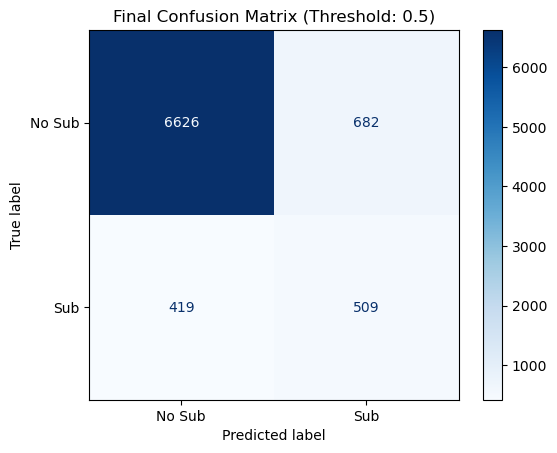

In [141]:
# Get predictions using the default 0.5 threshold for the final tuned model
y_pred_tuned_default = tuned_lgbm.predict(X_test)

print("--- TUNED MODEL CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_tuned_default))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_tuned_default)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Sub', 'Sub'])
print(cm)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Final Confusion Matrix (Threshold: 0.5)')
plt.show()

--- FINAL MODEL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.95      0.81      0.87      7308
           1       0.30      0.65      0.41       928

    accuracy                           0.79      8236
   macro avg       0.63      0.73      0.64      8236
weighted avg       0.88      0.79      0.82      8236

[[5918 1390]
 [ 324  604]]


<Figure size 800x600 with 0 Axes>

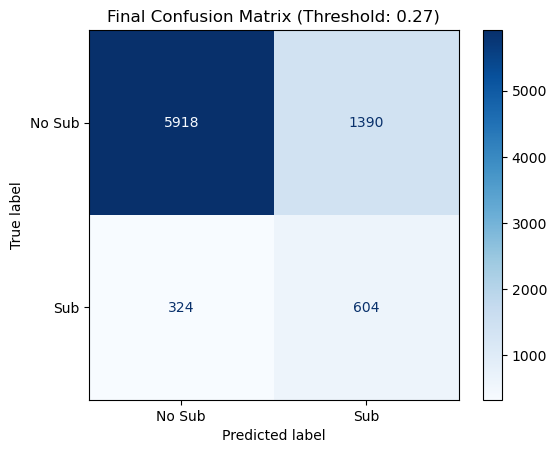

In [142]:
# Generate predictions using the chosen threshold
y_pred_final = (y_probs_tuned >= 0.27).astype(int)

# Classification Report
print("--- FINAL MODEL CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Sub', 'Sub'])
print(cm)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Final Confusion Matrix (Threshold: 0.27)')
plt.show()

**The "Balanced Outreach" Approach**

While the **Tuned Model (0.5 threshold)** provides high overall scores, we have selected a **custom threshold of 0.27** to better align with the bank's revenue goals and cost optimization needs.

**Threshold Comparison: 0.50 vs. 0.27**
| Metric | Tuned Baseline (0.50) | Balanced Strategy (0.27) | Shift |
| :--- | :--- | :--- | :--- |
| Recall (Class 1) | 55% | 65% | +10% Capture |
| Precision (Class 1) | 43% | 30% | -13% Quality |
| True Positives (Subscribers) | 509 | 604 | +95 Customers |
| False Negatives (Missed) | 419 | 324 | -95 Missed Ops |

**Why 0.27 is the Superior Business Choice**
1. **Maximizing Revenue Capture (Recall Focus)**
By moving the threshold to 0.27, we increased our Recall from **55% to 65%**. In practical terms, this means the model successfully identified an additional **95 subscribers** that the 0.5 threshold would have completely missed. At our estimated revenue of **€50 per sub**, this shift generates an extra **€4,750** in gross revenue for the bank.

2. **Reducing the "Cost of Silence" (False Negatives)**
In banking campaigns, the most "invisible" cost is the **Missed Opportunity**.
    * At the 0.5 threshold, we left **419** potential customers uncontacted.
    * At 0.27, we reduced those "Lost Sales" to **324**. By being slightly more aggressive, we ensure the bank isn't leaving money on the table for competitors to grab.

3. **Maintaining Professional Efficiency (Precision Control)**
We initially saw that a "Call Everyone" strategy (threshold 0.01) was profitable but highly inefficient. By settling at **0.27**, we hit a "Precision Floor" of **30%**.
    * **Insight**: 1 out of every 3.3 calls we make will result in a subscription.
    * While this is lower than the 43% precision of the baseline, it is significantly higher than the ~11% success rate of calling customers randomly. This maintains agent morale while maximizing the lead list.

## Model Interpretability
To ensure the model’s predictions are transparent and aligned with banking logic, we utilized two methods of interpretation: Global Feature Importance and SHAP (SHapley Additive exPlanations).

### Feature Importance: Global Drivers

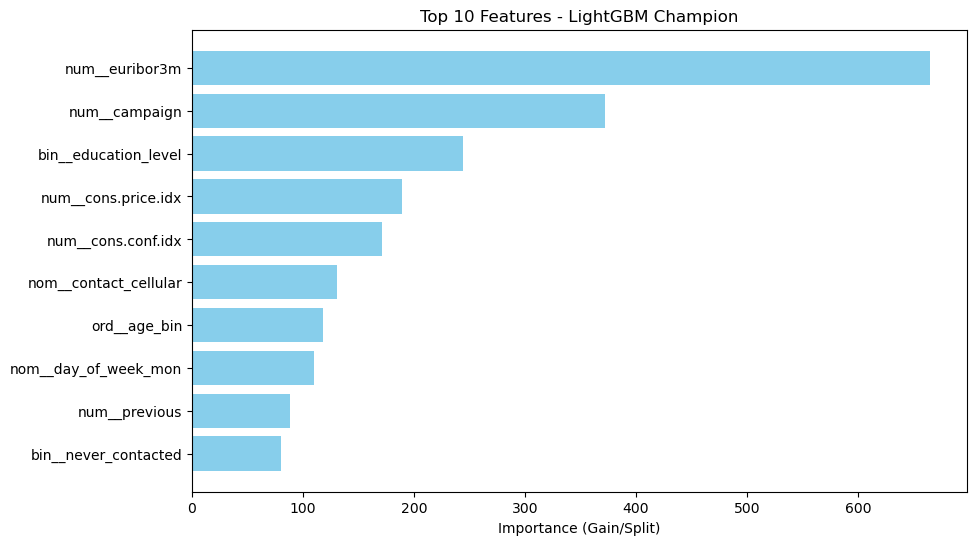

In [143]:
# Extract feature names after preprocessing
feature_names = tuned_lgbm.named_steps['preprocessor'].get_feature_names_out()

# Get importances from the classifier step
importances = tuned_lgbm.named_steps['classifier'].feature_importances_

# Create a DataFrame for easy plotting
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10) # Top 10

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
plt.xlabel('Importance (Gain/Split)')
plt.title('Top 10 Features - LightGBM Champion')
plt.gca().invert_yaxis()
plt.show()

The Feature Importance bar chart highlights which variables the LightGBM model relied on most frequently to distinguish between classes.
* **The Macroeconomic Dominance**: `num__euribor3m` is by far the most influential feature. This indicates that the client’s decision to subscribe is heavily tied to the 3-month interest rate environment.
* **Campaign Effort**: `num__campaign` (the number of contacts performed during this campaign) follows as the second most important feature, suggesting that persistence matters, but likely has diminishing returns.
* **Customer Sophistication**: `bin__education_level` and `num__cons.price.idx` also appear in the top five, showing that the model considers both the client's background and the current inflation environment.

### SHAP: Directional Impact
While global importance tells us which features matter, the SHAP summary plot reveals how they influence the probability of a subscription.

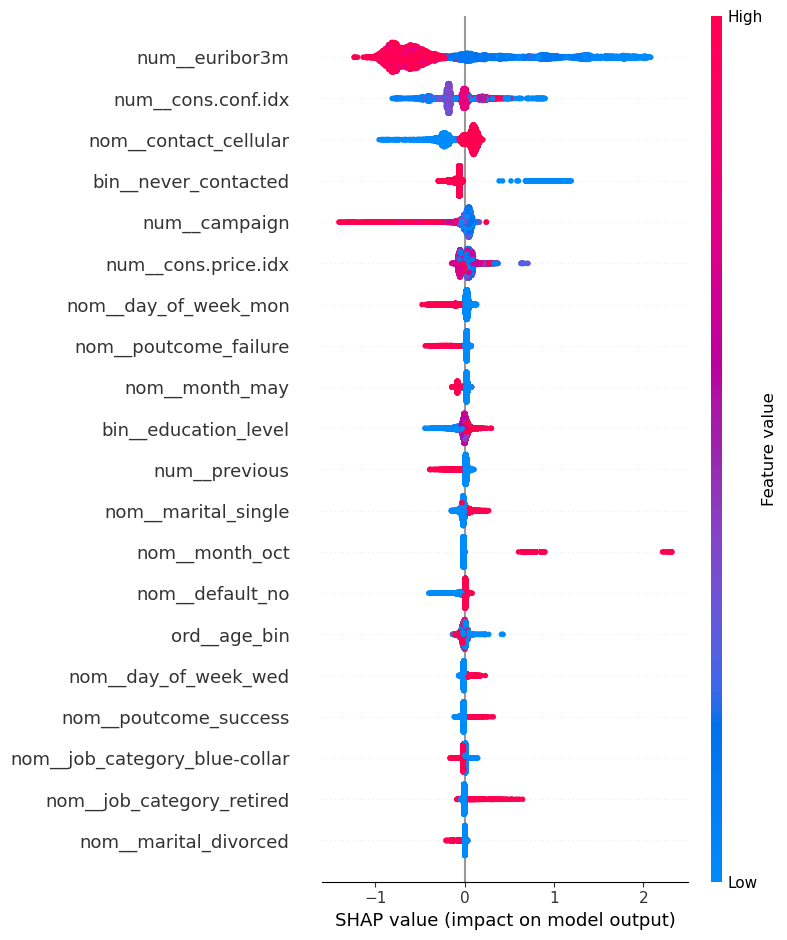

In [144]:
# We need to transform the data first because SHAP looks at the model input
X_test_transformed = tuned_lgbm.named_steps['preprocessor'].transform(X_test)

# Initialize the Explainer
explainer = shap.TreeExplainer(tuned_lgbm.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

# Plot (Summary Plot)
# Note: For binary classification, shap_values is often a list. Use [1] for the positive class.
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

* **The Euribor Effect**: We see a massive cluster of **red points (High Euribor rates)** on the **left side (Negative impact)**. This is a critical finding: **Higher interest rates significantly decrease the likelihood of a subscription**. In a high-rate environment, customers may be seeking higher-yield investments elsewhere or are more cautious with their liquidity.

* **The "Never Contacted" Advantage**: For `bin__never_contacted`, **blue points (Low/0 value)** are spread to the **right (Positive impact)**. This suggests that "fresh", leads—customers who haven't been bombarded with previous calls, are more likely to be receptive to the bank's offer.

* **Campaign Fatigue** (`num__campaign`): High values for the number of contacts (red points) show a strong negative impact on the model's output. This indicates **Campaign Fatigue**; the likelihood of a "Yes" drops significantly as the number of call attempts increases. Strategically, the bank should consider a "cap" on the number of calls per customer to avoid wasting resources on leads that have clearly soured.

* **Economic Confidence**: Higher Consumer Confidence (`num__cons.conf.idx`) and specific months like **October** (`nom__month_oct`) show positive pressure on subscriptions (points moving to the right), identifying specific economic windows where the sales team is most likely to succeed.

* **The Retired Profile**: Being **Retired** (`nom__job_category_retired`) has a very clear positive SHAP value. This demographic likely views term deposits as a safe and stable vehicle for their savings.

# Conclusion

This project successfully developed a refined **LightGBM** machine learning pipeline to optimize the Portuguese bank's term deposit campaigns. While a "Max Profit" mathematical approach suggests an aggressive calling strategy, our analysis identifies a **"Balanced Precision" strategy at a 0.27 threshold** as the most sustainable path.

By prioritizing **Precision (30%)** over sheer volume, the model allows the bank to capture **65% of all potential subscribers** while filtering out **81% of the uninterested leads**. This results in a high-quality outreach program that maximizes the impact of every call made, shifting the campaign from a "numbers game" to a data-driven "surgical" operation.

# Recommendation

**For the Marketing Team (Operational Efficiency)**
* **Implement a "Lead Scoring" Tier**: Use the model's probability scores to prioritize daily call lists. Focus resources on leads with a probability $> 0.27$.
* **The "Rule of Three"**: SHAP analysis shows that as `num_campaign` increases, the chance of success drops sharply. Marketing should test a "hard cap" of 3–5 contact attempts per lead. If they haven't subscribed by then, the data suggests they likely never will, and resources should be moved to "fresher" leads.
* **Prioritize Mobile Outreach**: The model identified `contact_cellular` as a positive driver. Ensure that mobile numbers are the primary point of contact for high-probability leads.

**For the Data Science Team (Model Evolution)**
* **Monitor Macro-Indicators**: Since `euribor3m` is the dominant feature, the model's performance will fluctuate with interest rate changes. Implement a quarterly "drift check" to see if the 0.27 threshold needs adjustment as the economy shifts.
* **Feature Engineering - Time-based Decay**: Since "never contacted" clients are more receptive, create a feature that tracks the "time since last campaign" to better capture the "Freshness" factor.
* **A/B Test the Threshold**: Run a pilot program where half the team uses the 0.27 threshold and the other half uses the 0.50 threshold to validate the real-world trade-off between Precision and Recall.

**For the Executive Board (Strategic Direction)**
* **Resource Allocation**: By adopting the 0.27 threshold, the bank can reduce total call volume by **~75%** while still capturing the majority of revenue. This allows for a significant reduction in operational overhead or the redirection of sales staff to other high-value products.
* **Economic Sensitivity**: Be aware that term deposit uptake is highly sensitive to the Euribor 3-month rate. During periods of rising rates, marketing budgets for term deposits should be adjusted, as the model shows customers become significantly less likely to subscribe.
* **Brand Protection**: Choosing a higher precision threshold (30%) reduces "telemarketing spam," protecting the bank's long-term reputation and customer relationship health.

# Save Model

In [145]:
# model name for saving
model_file_name = 'final_project_bank_model.pkl'

# Save the entire pipeline (preprocessor + model) for future use
model_to_save = {'pipeline': tuned_lgbm,
                 'optimal_threshold': 0.27  # Include the chosen threshold for deployment}
                 } 

with open(model_file_name, 'wb') as file:
    pickle.dump(model_to_save, file)

print(f" Model successfully saved as: {model_file_name}")

 Model successfully saved as: final_project_bank_model.pkl


# Streamlit
You can interact with the final model and test different customer scenarios here:
[**Bank Term Deposit Predictor - Live App**](https://jcdsi-02-02-alpha-final-project-bank-marketing-campaign.streamlit.app/)

# Tableau Public
You can also see an interactive EDA here: [**Bank Marketing Campaign Dashboard**](https://public.tableau.com/views/Final-Project_Bank-Marketing-CampaignLiefthaFaris/DataScienceDashboard?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)